<a href="https://colab.research.google.com/github/VGozzi/vnl-2024-stats-machine-learning-mvp/blob/main/mvp_machine_learning_and_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Vitor Martins Gozzi  
**Matrícula:** 4052026000264  
**Data:** 04/07/2026  
**Dataset:** VNL 2024 Men's Stats — [Kaggle](https://www.kaggle.com/datasets/jonathanpmoyer/vnl-2024-mens-stats)  
**Tipo de problema:** Clusterização não supervisionada

## 1. Definição do Problema

## 1.1 Descrição do problema
No voleibol moderno de alto nível, a especialização tática é crucial para o funcionamento do jogo em si. Ele é estruturado em torno de **cinco posições principais**, cada uma com funções rigidamente coordenadas para o funcionamento da equipe:

* **Levantador:** Considerado o cérebro do time, é responsável pela estratégia de jogo, pela distribuição das jogadas e pela armação do ataque.

* **Ponteiro:** O jogador mais equilibrado entre todos, que atua tanto na linha de frente do ataque pelas extremidades, tanto quanto carrega grande responsabilidade na recepção de saques e na defesa.

* **Oposto:** Normalmente a principal força ofensiva da equipe, acionado para finalizar jogadas de alta potência e liberado das obrigações de recepção para focar no ataque.

* **Central:** O especialista em bloqueios no meio da rede e em ataques de velocidade (curto tempo).

* **Líbero:** O especialista defensivo do time, que atua exclusivamente no fundo de quadra (recepção e defesa) e possui restrições de regras que o impedem de sacar ou atacar.

Como cada posição exige competências específicas, os atletas desenvolvem um perfil estatístico de ações muito distinto. Um líbero acumulará um volume massivo de defesas e passes, enquanto um central se destacará em bloqueio. Essa disparidade gera uma hipótese natural: será que essas cinco funções táticas formam, grupos "geometricamente" distintos, a ponto de um algoritmo conseguir descobri-los sozinho, sem nunca ter acesso ao rótulo de posição?

Para investigar essa questão, utilizamos o conjunto de dados da **Volleyball Nations League (VNL) 2024**, torneio que reúne a elite do voleibol mundial. Este projeto é uma evolução direta de um MVP anterior de Análise Exploratória de Dados (EDA), no qual observamos visualmente que as métricas de volume de jogo separam as posições com grande clareza (os pairplots da seção 4 repetiram parte da análise feita anteriormente). Essa separação visual é justamente o que motiva a escolha de **clusterização não supervisionada** como abordagem: se os grupos já aparecem nitidamente na EDA, é razoável esperar que um algoritmo de agrupamento consiga recuperá-los organicamente.

## 1.2 Objetivo do MVP

O objetivo deste MVP é aplicar e avaliar algoritmos de **clusterização não supervisionada** (K-Means, DBSCAN e clusterização hierárquica/HCA) sobre o perfil estatístico de volume de jogo dos atletas da VNL 2024, investigando até que ponto a estrutura geométrica intrínseca dos dados é suficiente para reconstruir, de forma totalmente orgânica, as cinco posições táticas do voleibol sem o uso de rótulos durante o treinamento.

A posição real de cada atleta (`Position`) é mantida exclusivamente como referência externa **após** a formação dos clusters, para medir, via Adjusted Rand Index (ARI), o quão bem a partição encontrada automaticamente coincide com a organização tática real do esporte.

## 1.3 Tipo de problema

* **Tipo escolhido:** Clusterização não supervisionada (*K-Means*, *DBSCAN* e clusterização hierárquica/*HCA*).
* **Justificativa:** A Análise Exploratória de Dados (seção 4) indicou uma separabilidade visual forte entre as posições. Os pairplots das variáveis `p_v_*` mostram grupos bem distintos, com pouca sobreposição entre a maioria das posições. Essa evidência visual motiva diretamente o uso de clusterização: se os grupos já são discerníveis a olho nu em duas dimensões, é razoável esperar que algoritmos formais de agrupamento, operando no espaço completo de seis dimensões, consigam recuperá-los de forma não supervisionada. O problema consiste, portanto, em avaliar se os clusters formados por cada algoritmo reproduzem as cinco posições táticas reais, usando o ARI e o Silhouette Score como métricas de validação.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses:**

1. **K-Means (k=5):** As seis features de volume relativo (`p_v_*`) produzem clusters suficientemente compactos e separados para que o K-Means, fixando `k=5` (uma para cada posição tática), atinja ARI $> 0,70$ contra os rótulos reais. Espera-se que Levantador e Líbero sejam recuperados com alta pureza (por terem discriminadores quase exclusivos: `p_v_Set` e `p_v_Receive`), enquanto a sobreposição entre Oposto, Ponteiro e Central deve ser a principal fonte de erro.

2. **DBSCAN:** Devido à variação de densidade entre as posições (Ponteiro é numeroso e difuso no espaço de features; Líbero é compacto mas minoritário), o DBSCAN terá dificuldade em isolar exatamente 5 clusters sem ruído. Espera-se que ele produza um número de clusters diferente de 5 e/ou classifique uma fração não desprezível dos atletas como ruído, especialmente na zona de fronteira entre Oposto, Ponteiro e Central.

3. **HCA (clusterização hierárquica aglomerativa):** Com o linkage adequado (testado via busca entre `ward`, `complete`, `average` e `single`), a HCA atinge ARI $> 0,70$ com `k=5`, em desempenho comparável ao K-Means. Além disso, o dendrograma resultante deve refletir a proximidade tática esperada: Levantador e Líbero se separando do restante em alturas de fusão elevadas, enquanto Oposto, Ponteiro e Central se fundem em alturas mais baixas, confirmando a sobreposição estatística já observada na EDA.

**Critérios de Sucesso**
* **Métricas principais:** **ARI** (*Adjusted Rand Index*), para medir a concordância entre os clusters encontrados e as posições reais, e **Silhouette Score**, para medir a coesão interna dos clusters de forma totalmente independente dos rótulos.
* **Justificativa metodológica:** o ARI corrige a concordância ao acaso, sendo a métrica padrão para comparar uma partição não supervisionada contra um rótulo conhecido. O Silhouette complementa essa avaliação ao não depender de rótulo algum, servindo também para escolher o número de clusters (`k`), os hiperparâmetros de densidade (`eps`, `min_samples`) ou o critério de linkage da HCA de forma puramente intrínseca.
* **Resultados mínimos esperados:** **ARI $> 0,70$** para K-Means e HCA com `k=5`. Para o DBSCAN, o critério de sucesso é qualitativo: confirmar (ou refutar) a dificuldade prevista na Hipótese 2.
* **Restrições práticas e robustez:** padronização (`StandardScaler`) ajustada sobre o mesmo conjunto de dados usado na clusterização, evitando que variáveis com maior variância (como `p_v_Set`) dominem as métricas de distância.

# 2. Ambiente, bibliotecas e reprodutibilidade

## 2.1 Dependências adicionais

Além do ecossistema científico padrão (`pandas`, `numpy`, `scikit-learn`, `matplotlib`/`seaborn`), este projeto depende da biblioteca [`kagglehub`](https://pypi.org/project/kagglehub/), utilizada exclusivamente para o download programático do dataset diretamente do Kaggle — garantindo reprodutibilidade total sem a necessidade de configuração manual de credenciais de API.

In [ ]:
# 1. Bibliotecas padrão do Python
import os
import sys
import time
import random
import warnings

# 2. Manipulação e análise de dados
import pandas as pd
import numpy as np
import math

# 3. Visualização de dados e customização de gráficos
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# 4. Download programático do dataset do Kaggle
import kagglehub

# 5. Scikit-Learn: Pré-processamento
from sklearn.preprocessing import StandardScaler

# 6. Scikit-Learn: Clusterização, Redução de Dimensionalidade e Métricas
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

# 7. SciPy: dendrograma da clusterização hierárquica
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

warnings.filterwarnings("ignore")

SEED = 99
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 99


# 3. Seleção e carga dos dados


## 3.1 Fonte dos dados
O conjunto de dados selecionado para este projeto intitula-se **VNL 2024 Men's Stats**, hospedado e extraído publicamente da plataforma Kaggle através do link oficial: [Jonathan Moyer - VNL 2024 Men's Stats](https://www.kaggle.com/datasets/jonathanpmoyer/vnl-2024-mens-stats).

### Detalhes técnicos e fragmentação original:
A base de dados consolida as estatísticas oficiais de desempenho esportivo coletadas pela Federação Internacional de Voleibol (FIVB) durante a Volleyball Nations League (VNL) de 2024. Como mapeado no trabalho anterior, o ecossistema original dos dados encontra-se fragmentado em **8 arquivos independentes no formato `.csv`**, correspondendo a cada um dos fundamentos táticos e cadastros dos atletas:
1.  `VNL2024Men_Players.csv` (Dados cadastrais e posições oficiais dos atletas)
2.  `VNL2024Men_Attackers.csv` (Estatísticas detalhadas de ataque)
3.  `VNL2024Men_Diggers.csv` (Estatísticas detalhadas de defesa)
4.  `VNL2024Men_Blockers.csv` (Estatísticas detalhadas de bloqueio)
5.  `VNL2024Men_Receivers.csv` (Estatísticas detalhadas de recepção de saque)
6.  `VNL2024Men_Servers.csv` (Estatísticas detalhadas de saque)
7.  `VNL2024Men_Setters.csv` (Estatísticas detalhadas de levantamento)
8.  `VNL2024Men_Scorers.csv` (Pontuação geral agregada)

### Justificativa de escolha e continuidade do MVP:
A escolha deste conjunto justifica-se por fornecer o cenário empírico perfeito para investigar se as "assinaturas estatísticas" que diferenciam as 5 posições táticas do voleibol moderno (sistema tático 5x1) (Levantador - `S`, Líbero - `L`, Central - `MB`, Ponteiro - `OH` e Oposto - `O`). Tomando os achados do MVP anterior, **focamos nossa modelagem exclusivamente nos volumes totais de ações de cada fundamento**. A exploração anterior provou matematicamente que avaliar os dados pelas métricas de eficiência técnica resulta em uma altíssima sobreposição entre as diferentes posições, não se comportando como estatísticas robustas ou discriminantes para modelos de Clusterização. Em contrapartida, o volume bruto acumulado é onde reside a verdadeira identidade de cada função tática, gerando padrões quantitativos consistentes e ideais para que algoritmos de clusterização consigam separar os atletas em grupos coerentes, sem qualquer acesso ao rótulo de posição durante o agrupamento.

## 3.2 Carga e reconstrução dos dados

O carregamento do dataset é efetuado diretamente do repositório público do Kaggle por meio da biblioteca `kagglehub`.

O pipeline abaixo reconstrói a estrutura unificada dos dados a partir dos 8 arquivos fragmentados originais. O procedimento adota a tabela cadastral de atletas (`VNL2024Men_Players.csv`) como nossa base primária e realiza sucessivas operações de fusão (*Left Joins*) utilizando como chave composta os atributos textuais `Name` (Nome) e `Team` (Seleção).

Em alinhamento direto com as conclusões do MVP anterior, isolamos exclusivamente as colunas identificadoras, a variável-alvo (`Position`) e as 6 variáveis de volume total de ações por fundamento, tratando os sufixos duplicados gerados nas junções.

In [1]:
try:
    # Faz o download programático da versão mais recente do dataset via API do kagglehub
    path = kagglehub.dataset_download("jonathanpmoyer/vnl-2024-mens-stats")

    # Lista os arquivos disponíveis no diretório baixado para auditoria de carga
    print("Arquivos detectados no diretório do dataset:", os.listdir(path))

#TODO: preciso fazer um processo para pegar o csv caso n funcione o kagglehub
except Exception as e:
    path = "https://raw.githubusercontent.com/VGozzi/vnl-2024-stats-machine-learning-mvp/main/dataset"
    print(f"kagglehub indisponível ({e}). Usando fallback do GitHub: {path}")

kagglehub indisponível (name 'kagglehub' is not defined). Usando fallback do GitHub: https://raw.githubusercontent.com/VGozzi/vnl-2024-stats-machine-learning-mvp/main/dataset


In [ ]:

# Carrega todos os sub-datasets de estatísticas da VNL 2024 Masculina
dfs_bruto = [
    pd.read_csv(f'{path}/VNL2024Men_Players.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Attackers.csv', encoding='latin1'),
    pd.read_csv(f'{path}/VNL2024Men_Diggers.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Blockers.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Receivers.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Servers.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Setters.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Scorers.csv')
]

# Consolida os arquivos fragmentados através de Joins consecutivos pelas chaves biunívocas
df_bruto = dfs_bruto[0].copy()
for i in dfs_bruto[1:]:
    df_bruto = pd.merge(
        df_bruto,
        i,
        on=['Name', 'Team'],
        how='left'
    )

# Seleciona estritamente as colunas identificadoras, o target e os volumes totais
colunas_totais = [
    'Team',
    'Name',
    'Position',
    'Tot_Attack',    # Total de ações de ataque tentadas/efetuadas
    'T_Dig',         # Total de defesas de campo
    'Tot_Block_x',   # Total de toques e pontos de bloqueio
    'Tot_Receive',   # Total de ações de recepção de saque (passe)
    'Tot_Serve_x',   # Total de saques executados
    'Tot_Set'        # Total de levantamentos/armações realizados
]

df_fundamentos = df_bruto[colunas_totais].copy()


# Mapeamento de nomes das posições
mapeamento_posicoes = {
    'OH': 'Ponteiro',
    'L': 'Libero',
    'S': 'Levantador',
    'MB': 'Central',
    'O': 'Oposto'
}

# Aplicar a substituição na coluna 'Position'
df_fundamentos['Position'] = df_fundamentos['Position'].replace(mapeamento_posicoes)

# Limpeza de nomenclatura: remove os sufixos temporários '_x' herdados dos merges
df_fundamentos.columns = [col.replace('_x', '') for col in df_fundamentos.columns]

# Exibe a amostragem inicial do dataframe consolidado pronto para modelagem
df_fundamentos

,Team,Name,Position,Tot_Attack,T_Dig,Tot_Block,Tot_Receive,Tot_Serve,Tot_Set
0,ARG,Armoa Morel,Ponteiro,NaN,NaN,NaN,NaN,NaN,NaN
1,ARG,Conte,Ponteiro,211.0,76.0,63.0,180.0,118.0,48.0
2,ARG,Danani,Libero,0.0,188.0,0.0,233.0,2.0,54.0
3,ARG,De Cecco,Levantador,24.0,75.0,61.0,5.0,135.0,966.0
4,ARG,Gallego,Central,5.0,2.0,5.0,0.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...
299,USA,Russell,Ponteiro,52.0,21.0,12.0,60.0,30.0,4.0
300,USA,Smith,Central,18.0,10.0,26.0,4.0,19.0,3.0
301,USA,Tuaniga,Levantador,3.0,13.0,12.0,1.0,16.0,173.0
302,USA,Wetter,Ponteiro,3.0,2.0,3.0,1.0,4.0,0.0


## 3.3 Visão geral do dataset
O conjunto de dados resultante apresenta o formato inicial de **304 linhas (instâncias) e 9 colunas (atributos)**.

O dataset é composto por duas variáveis textuais de identificação (`Team` e `Name`), uma variável categórica nominal (`Position`) que indica a posição tática oficial do atleta e será usada apenas como referência de validação após a clusterização, e 6 variáveis numéricas contínuas (`Tot_Attack`, `T_Dig`, `Tot_Block`, `Tot_Receive`, `Tot_Serve`, `Tot_Set`) que mensuram o volume bruto de ações físicas executadas por cada atleta.

In [ ]:
print(f"Formato inicial do dataset: {df_fundamentos.shape[0]} linhas e {df_fundamentos.shape[1]} colunas.")

Formato inicial do dataset: 304 linhas e 9 colunas.


In [ ]:
# Verifica se existem linhas duplicadas no dataset
total_duplicadas = df_fundamentos.duplicated().sum()
print(f"\nTotal de registros completamente duplicados: {total_duplicadas}")
if total_duplicadas > 0:
    duplicados = df_fundamentos[df_fundamentos.duplicated(keep=False)]
    print(duplicados)

# Remove duplicados mantendo a primeira ocorrência
df_fundamentos = df_fundamentos.drop_duplicates()


Total de registros completamente duplicados: 1
   Team        Name Position  Tot_Attack  T_Dig  Tot_Block  Tot_Receive  \
89  FRA  Chinenyeze  Central        23.0    2.0       13.0          1.0   
90  FRA  Chinenyeze  Central        23.0    2.0       13.0          1.0   

    Tot_Serve  Tot_Set  
89       17.0      0.0  
90       17.0      0.0  


In [ ]:
# Colunas quantitativas de interesse
cols = ['Tot_Attack', 'T_Dig', 'Tot_Block', 'Tot_Receive', 'Tot_Serve', 'Tot_Set']

print(f"\nTotal de registros inicial: {len(df_fundamentos)}")

# Substitui NaNs por 0 (Tratamento de nulos parciais)
df_clean = df_fundamentos.copy()
df_clean[cols] = df_clean[cols].fillna(0)

# Identifica linhas totalmente zeradas.
# Se a soma dos valores absolutos for 0, a linha inteira é inválida
linhas_vazias = df_clean[cols].abs().sum(axis=1) == 0

# Filtra o DataFrame mantendo apenas quem tem dados úteis
df_clean = df_clean[~linhas_vazias].copy()

print("\n--- Pós-Tratamento ---")
print(f"Total de registros removidos (nulos ou zerados): {linhas_vazias.sum()}")
print(f"Total de registros limpos para modelagem: {len(df_clean)}")
print(f"Dimensões finais do dataset: {df_clean.shape}\n")


Total de registros inicial: 303

--- Pós-Tratamento ---
Total de registros removidos (nulos ou zerados): 21
Total de registros limpos para modelagem: 282
Dimensões finais do dataset: (282, 9)



> ### Tratamento de valores ausentes e de perfis vazios

> Para garantir a integridade da modelagem, os registros foram tratados de acordo com a extensão e o significado técnico das suas ausências:

> - **Perfis vazios (Removido):** Linhas que apresentavam ausência total de dados — seja por omissão de registro (NaN em todas as colunas) ou por zeragem integral (0 em todos os fundamentos) — foram descartadas. Esses casos indicam que o atleta não teve participação ativa ou que seus dados não foram coletados, não gerando nenhum sinal tático aproveitável.

> - **Ausências Parciais (Imputação por Zero):** Registros com omissões em apenas alguns fundamentos foram mantidos, e as lacunas foram preenchidas com zero. No contexto do voleibol, a ausência de um registro é informativa: um levantador com Tot_Receive = NaN, por exemplo, provavelmente não executou recepções no jogo. Imputar zero preserva essa característica tática real em vez de tratá-la como um erro de sistema.

> Como os dados nulos parciais são convertidos em zero antes da validação final, a estratégia elimina o risco de linhas "mistas" (combinação de NaN e zeros) passarem despercebidas. Isso consolida a limpeza em um único fluxo e garante que nenhuma divisão por zero ($0 \div 0$) ocorra nas etapas subsequentes.

In [ ]:
# Data Set tratado
df_clean.info()

print("\nAmostragem aleatória de 5 registros do dataset tratado:")
display(df_clean.sample(5, random_state=SEED))

<class 'pandas.core.frame.DataFrame'>
Index: 282 entries, 1 to 303
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Team         282 non-null    object 
 1   Name         282 non-null    object 
 2   Position     282 non-null    object 
 3   Tot_Attack   282 non-null    float64
 4   T_Dig        282 non-null    float64
 5   Tot_Block    282 non-null    float64
 6   Tot_Receive  282 non-null    float64
 7   Tot_Serve    282 non-null    float64
 8   Tot_Set      282 non-null    float64
dtypes: float64(6), object(3)
memory usage: 22.0+ KB

Amostragem aleatória de 5 registros do dataset tratado:


,Team,Name,Position,Tot_Attack,T_Dig,Tot_Block,Tot_Receive,Tot_Serve,Tot_Set
157,ITA,Michieletto,Ponteiro,197.0,46.0,49.0,156.0,133.0,38.0
50,BUL,Petrov,Ponteiro,6.0,2.0,3.0,8.0,2.0,2.0
188,NED,De Weijer,Levantador,0.0,2.0,1.0,0.0,2.0,23.0
169,JPN,Kai,Ponteiro,130.0,39.0,25.0,135.0,81.0,15.0
3,ARG,De Cecco,Levantador,24.0,75.0,61.0,5.0,135.0,966.0


# 4. Análise Exploratória dos Dados (EDA)

Nesta seção, investigamos a distribuição da posição e o comportamento dos atributos de volume de jogo — tanto os absolutos (`Tot_*`) quanto os normalizados após a engenharia de features (`p_v_*`), segmentados por cada posição tática. O objetivo é validar visualmente as assinaturas estatísticas de cada função em quadra, além de diagnosticar potenciais anomalias, como desbalanceamento de classes ou vieses amostrais, garantindo a integridade dos dados antes da etapa de modelagem.

## 4.1 Funções auxiliares

Esta seção concentra as funções de visualização reutilizadas ao longo da análise exploratória (distribuição do target, matriz de histogramas por posição e pairplots).

In [ ]:
def plot_distribuicao_posicao(df, cores_posicao):
    """Gráfico de barras com contagem de atletas por posição."""
    ordem = df['Position'].value_counts().index
    ax = sns.countplot(data=df, x='Position', order=ordem, palette=cores_posicao, hue='Position', legend=False)

    # Anota o valor exato no topo de cada barra
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

    # Definição de Títulos e labels
    plt.title('Distribuição da Quantidade de Atletas por Posição', fontsize=16, pad=10)
    plt.xlabel('Posição Tática', fontsize=12)
    plt.ylabel('Número de Jogadores', fontsize=12)
    ax.set_ylim(0, df['Position'].value_counts().max() * 1.1)
    plt.show()

def plot_matriz_atributos(df, cores_posicao, posicoes_ordem=None):
    """Matriz de histogramas comparando todos os atributos numéricos por posição."""
    if posicoes_ordem is None:
        posicoes_ordem = list(cores_posicao.keys())

    atributos = df.select_dtypes(include=['number']).columns
    fig, axes = plt.subplots(len(atributos), len(posicoes_ordem),
                             figsize=(4 * len(posicoes_ordem), len(atributos) * 4), squeeze=False)
    sns.set_theme(style="whitegrid")

    # Itera sobre cada atributo e posição para preencher a matriz
    for row_idx, atri in enumerate(atributos):
        for col_idx, pos in enumerate(posicoes_ordem):
            ax = axes[row_idx, col_idx]
            dados_celula = df[df['Position'] == pos][atri].dropna()

            if not dados_celula.empty:
                media, mediana = dados_celula.mean(), dados_celula.median()

                # Histograma com KDE e linhas de média e mediana
                sns.histplot(x=dados_celula, bins=10, kde=True, ax=ax,
                             color=cores_posicao.get(pos, 'gray'), alpha=0.6, edgecolor='white')
                ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
                ax.axvline(mediana, color='black', linestyle=':', linewidth=2, label=f'Mediana: {mediana:.2f}')
                ax.legend(loc='upper right', fontsize=9, frameon=True)

            # Títulos e labels apenas nas bordas da matriz
            if row_idx == 0: ax.set_title(f'Posição: {pos}', fontsize=16, fontweight='bold', pad=15)
            ax.set_ylabel('Frequência' if col_idx == 0 else '', fontsize=12, fontweight='bold')

    plt.tight_layout(pad=3.0)
    plt.show()

def plot_boxplots_atributos(df, cores_posicao, posicoes_ordem=None, cols_per_row=3):
    """Grade de boxplots para todos os atributos numéricos, comparados por posição."""
    atributos = df.select_dtypes(include=['number']).columns
    if posicoes_ordem is None: posicoes_ordem = ['OH', 'MB', 'S', 'O', 'L']

    # Calcula o número de linhas necessárias para acomodar todos os atributos
    num_rows = math.ceil(len(atributos) / cols_per_row)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(20, num_rows * 5), constrained_layout=False)
    axes_flat = axes.flatten() if len(atributos) > 1 else [axes]

    # Plota um boxplot por atributo
    for i, atri in enumerate(atributos):
        ax = axes_flat[i]
        sns.boxplot(data=df, x='Position', y=atri, order=posicoes_ordem, ax=ax,
                    palette=cores_posicao, hue='Position', legend=False, fliersize=4)
        ax.set_title(f'Distribuição: {atri}', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Posição', fontsize=10)
        ax.set_ylabel('Valores Brutos', fontsize=10)
        sns.despine(ax=ax, left=True)

    # Remove eixos vazios que sobram na grade
    for j in range(i + 1, len(axes_flat)): fig.delaxes(axes_flat[j])

    plt.tight_layout(pad=3.0)
    plt.show()

def build_pairplot(x_vars, y_vars, titulo, df, posicoes_ordem, cores_posicao):
    """ Recorte do PairPlot completo dos atributos para cada variável (p_v_* e P_ef_*)."""
    sns.set_theme(style="whitegrid")
    # Gerar o pairplot cortado para a variaveis selecionadas
    pp = sns.pairplot(
        df,
        x_vars=x_vars,
        y_vars=y_vars,
        hue='Position',
        hue_order=posicoes_ordem,
        palette=cores_posicao,
        diag_kind='kde' if x_vars == y_vars else None,
        height=3.5,
        aspect=1.1,
        plot_kws={'alpha': 0.5, 's': 120, 'edgecolor': 'w', 'linewidth': 0.5},
        diag_kws={'fill': True, 'alpha': 0.4}
    )

    # Criar handles para a legenda
    legend_elements = [
        mpatches.Patch(color=cores_posicao.get(pos, 'gray'), label=pos)
        for pos in posicoes_ordem
    ]

    # Customização de legendas label's e afins
    for i, y_var in enumerate(y_vars):
        for j, x_var in enumerate(x_vars):
            ax = pp.axes[i, j]
            if ax is None: continue
            ax.tick_params(labelbottom=True, labelleft=True, labelsize=8)
            if i == j and x_var == y_var:
                ax.set_xlabel(x_var.replace('_', ' ').title(), fontsize=10, fontweight='bold')
                ax.set_ylabel('')
            else:
                ax.set_xlabel(x_var.replace('_', ' ').title(), fontsize=10, fontweight='bold')
                ax.set_ylabel(y_var.replace('_', ' ').title(), fontsize=10, fontweight='bold')
            ax.xaxis.label.set_visible(True)
            ax.yaxis.label.set_visible(True)
            ax.legend(handles=legend_elements, loc='upper right',
                      fontsize=7, frameon=True, framealpha=0.6)
            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_axisbelow(True)

    # Ajustes os subplots
    pp.fig.suptitle(titulo, fontsize=26, fontweight='bold', y=0.88)
    plt.subplots_adjust(top=0.85, hspace=0.35, wspace=0.3, left=0.07, right=0.97)
    if pp._legend:
        pp._legend.remove()

    plt.show()

## 4.2 Visualização das distribuições por posição


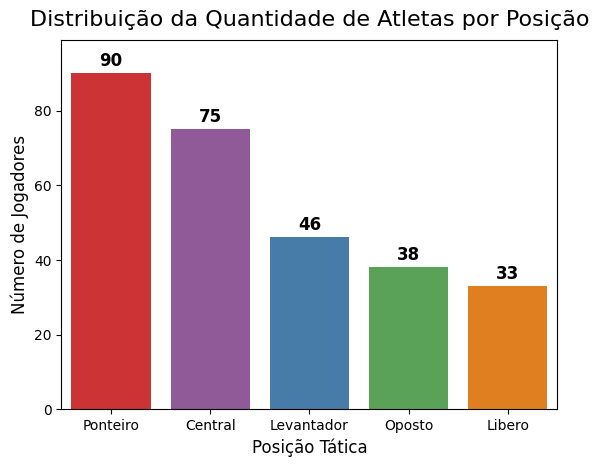

In [ ]:
# Mapeamento manual para garantir as cores para cada atributo
paleta = sns.color_palette('Set1')
cores_posicao = {
    'Ponteiro': paleta[0],    # Vermelho
    'Levantador':  paleta[1], # Azul
    'Oposto':  paleta[2],     # Verde
    'Central': paleta[3],     # Roxo
    'Libero':  paleta[4]      # Laranja
}

# Plota as distribução da quantidade de atletas por Posição
plot_distribuicao_posicao(df_clean, cores_posicao)

> O gráfico de distribuição revela uma disparidade numérica entre as posições, com predominância de Ponteiros (OH) e Centrais (MB). Esse comportamento é inerente à dinâmica do voleibol, que utiliza dois atletas de cada uma dessas funções em quadra, contra apenas um Levantador (S), Oposto (O) e Líbero (L). A ligeira superioridade quantitativa de Ponteiros em relação a Centrais, e de Levantadores em relação a Líberos, reflete na maior exigência desses jogadores em quadra, sendo necessário um maior volume de substituições nessas funções específicas.

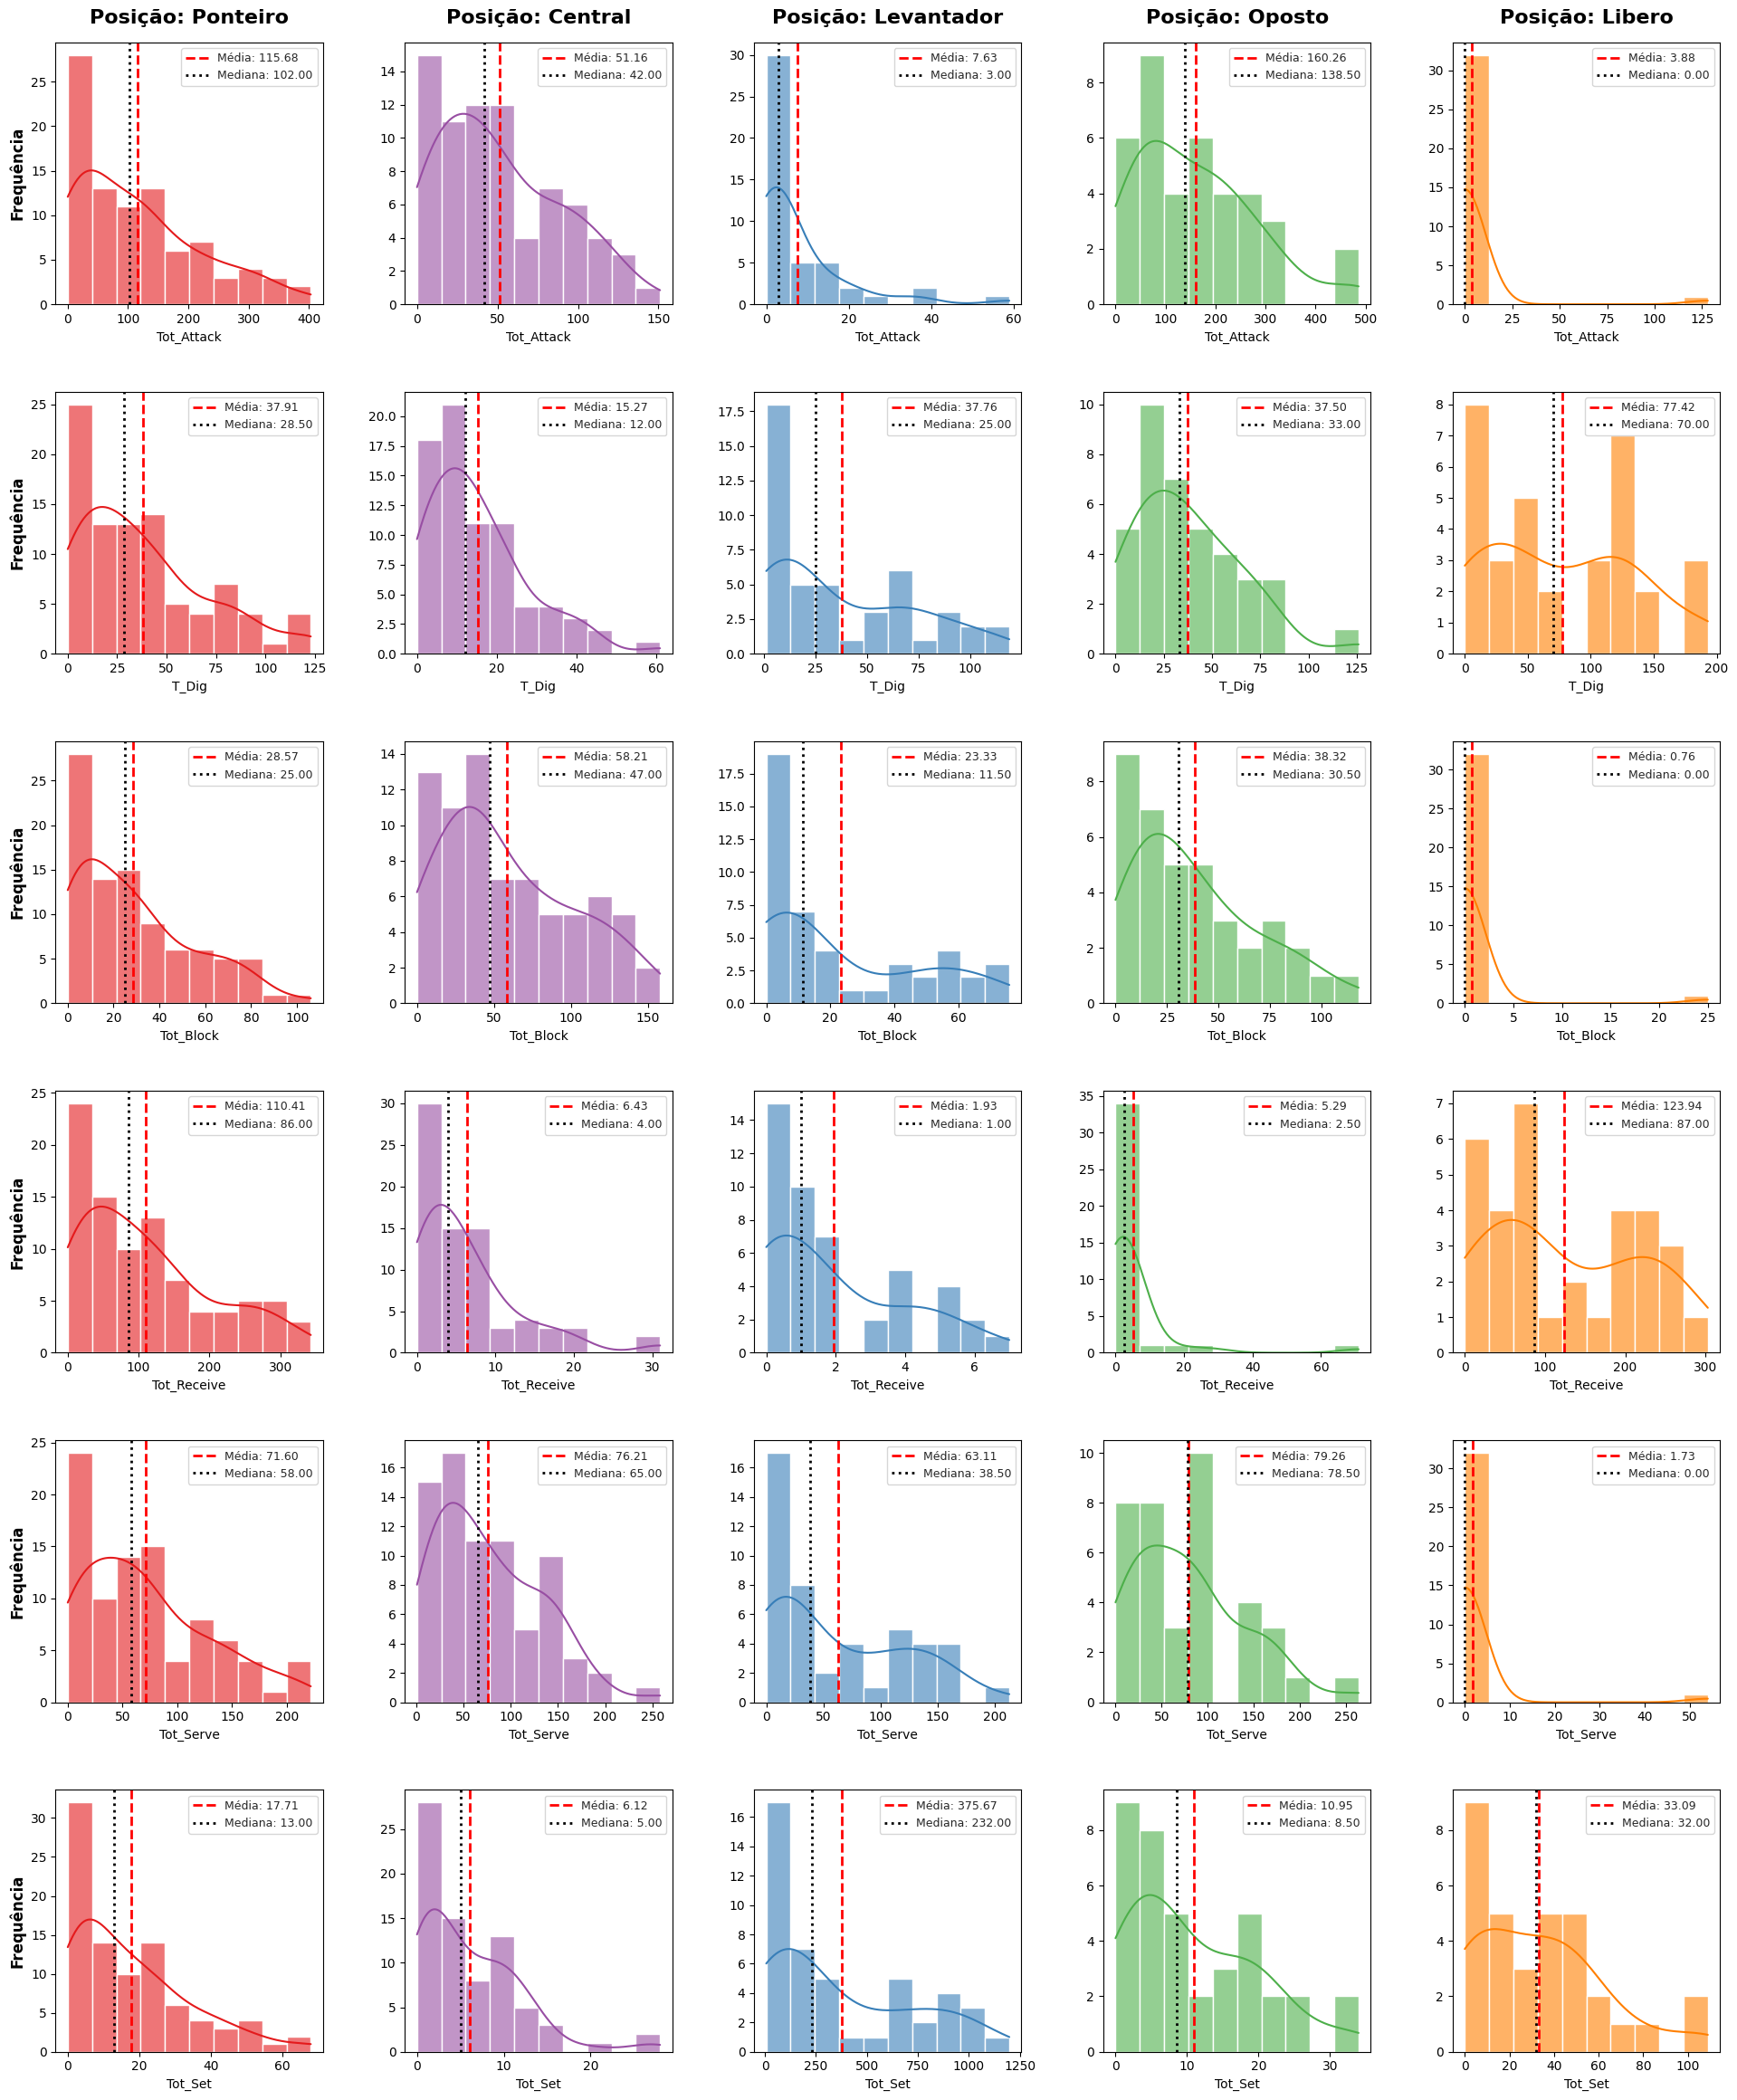

In [ ]:
ordem = ['Ponteiro', 'Central', 'Levantador', 'Oposto', 'Libero']

# Escalas dos eixos X e Y são independentes por gráfico, priorizando
# a visualização da forma de cada distribuição em vez da comparação direta de magnitude.
plot_matriz_atributos(df_clean, cores_posicao, ordem)

> A análise da matriz de distribuição revela uma forte concentração de registros próximos à origem, reflexo direto da **disparidade de minutagem** entre atletas titulares e reservas. Esse fenômeno evidencia um viés de amostragem condicionado pela participação em jogo, resultando em uma distribuição com **assimetria positiva** (a média se desloca à direita da mediana, indicando um alongamento da cauda direita da distribuição). Essa assimetria compromete diretamente a capacidade de distinção entre posições, pois um reserva com poucos toques produz um perfil estatístico quase nulo, independente da sua função tática.

### 4.3 Feature engineering

Para mitigar o viés de minutagem identificado acima e tornar as estatísticas comparáveis entre jogadores, utilizamos a **proporção relativa do fundamento** (`p_v_*`): a proporção de cada tipo de ação sobre o total de ações do jogador. Essa métrica não mede qualidade técnica, e sim a participação relativa do atleta naquele fundamento, atenuando o efeito do tempo de jogo.

In [ ]:
# Calcula o total de todas as ações de um jogador
df_clean['Total_Geral'] = df_clean[cols].sum(axis=1)
df_clean.head()

# Cria as novas colunas de volume relativo (p_v_*)
for col in cols:
    nome_base = col.replace('Tot_', '').replace('T_', '')
    nome_nova_col = f'p_v_{nome_base}'
    df_clean[nome_nova_col] = df_clean[col] / df_clean['Total_Geral']

# Seleciona apenas as colunas identificadoras + as novas features p_v
colunas_dados = [col for col in df_clean.columns if col.startswith('p_v_')]
colunas_finais = ['Team', 'Name', 'Position'] + colunas_dados

# dropna como salvaguarda (não deve remover nada após o filtro acima)
df_final = df_clean[colunas_finais].dropna(subset=colunas_dados, how='all').copy()

print(f"Dimensões finais do df_final: {df_final.shape[0]} atletas × {df_final.shape[1]} colunas")
display(df_final.sample(5, random_state=SEED))


Dimensões finais do df_final: 282 atletas × 9 colunas


,Team,Name,Position,p_v_Attack,p_v_Dig,p_v_Block,p_v_Receive,p_v_Serve,p_v_Set
157,ITA,Michieletto,Ponteiro,0.318255,0.074313,0.079160,0.252019,0.214863,0.061389
50,BUL,Petrov,Ponteiro,0.260870,0.086957,0.130435,0.347826,0.086957,0.086957
188,NED,De Weijer,Levantador,0.000000,0.071429,0.035714,0.000000,0.071429,0.821429
169,JPN,Kai,Ponteiro,0.305882,0.091765,0.058824,0.317647,0.190588,0.035294
3,ARG,De Cecco,Levantador,0.018957,0.059242,0.048183,0.003949,0.106635,0.763033


## 4.4 Dicionário de dados

A tabela a seguir apresenta a especificação técnica dos atributos utilizados na modelagem, após o processo de normalização (*Feature Engineering*), onde as métricas de volume absoluto foram convertidas em frequências relativas.

| Atributo | Tipo / Escala | Descrição | Utilizado? | Justificação Técnica |
| :--- | :--- | :--- | :---: | :--- |
| **Team** | `string`<br>Nominal | Seleção nacional do<br>atleta na VNL 2024. | **Não** | Metadado de identificação.<br>Evita sobreajuste (*overfitting*). |
| **Name** | `string`<br>Nominal | Nome oficial do atleta<br>na competição. | **Não** | Metadado de identificação.<br>Evita sobreajuste (*overfitting*). |
| **p_v_Attack** | `float64`<br>Razão [0-1] | Frequência relativa de ataques. | **Sim** | Define a carga ofensiva do atleta (ex: Opostos). |
| **p_v_Dig** | `float64`<br>Razão [0-1] | Frequência relativa de defesas. | **Sim** | Identifica especialistas defensivos (Líberos). |
| **p_v_Block** | `float64`<br>Razão [0-1] | Frequência relativa de bloqueios. | **Sim** | Assinatura tática distintiva do Central. |
| **p_v_Receive** | `float64`<br>Razão [0-1] | Frequência relativa de passes. | **Sim** | Identifica atletas com perfil de recepção. |
| **p_v_Serve** | `float64`<br>Razão [0-1] | Frequência relativa de saques. | **Sim** | Pondera o peso do saque no perfil tático. |
| **p_v_Set** | `float64`<br>Razão [0-1] | Frequência relativa de levantamentos. | **Sim** | Característica excludente do Levantador. |
| **Position** | `string`<br>Nominal | Posição tática (Ponteiro, Líbero, etc.) | **Não (apenas validação)** | Não é usada como feature; serve só para calcular o ARI após a clusterização. |

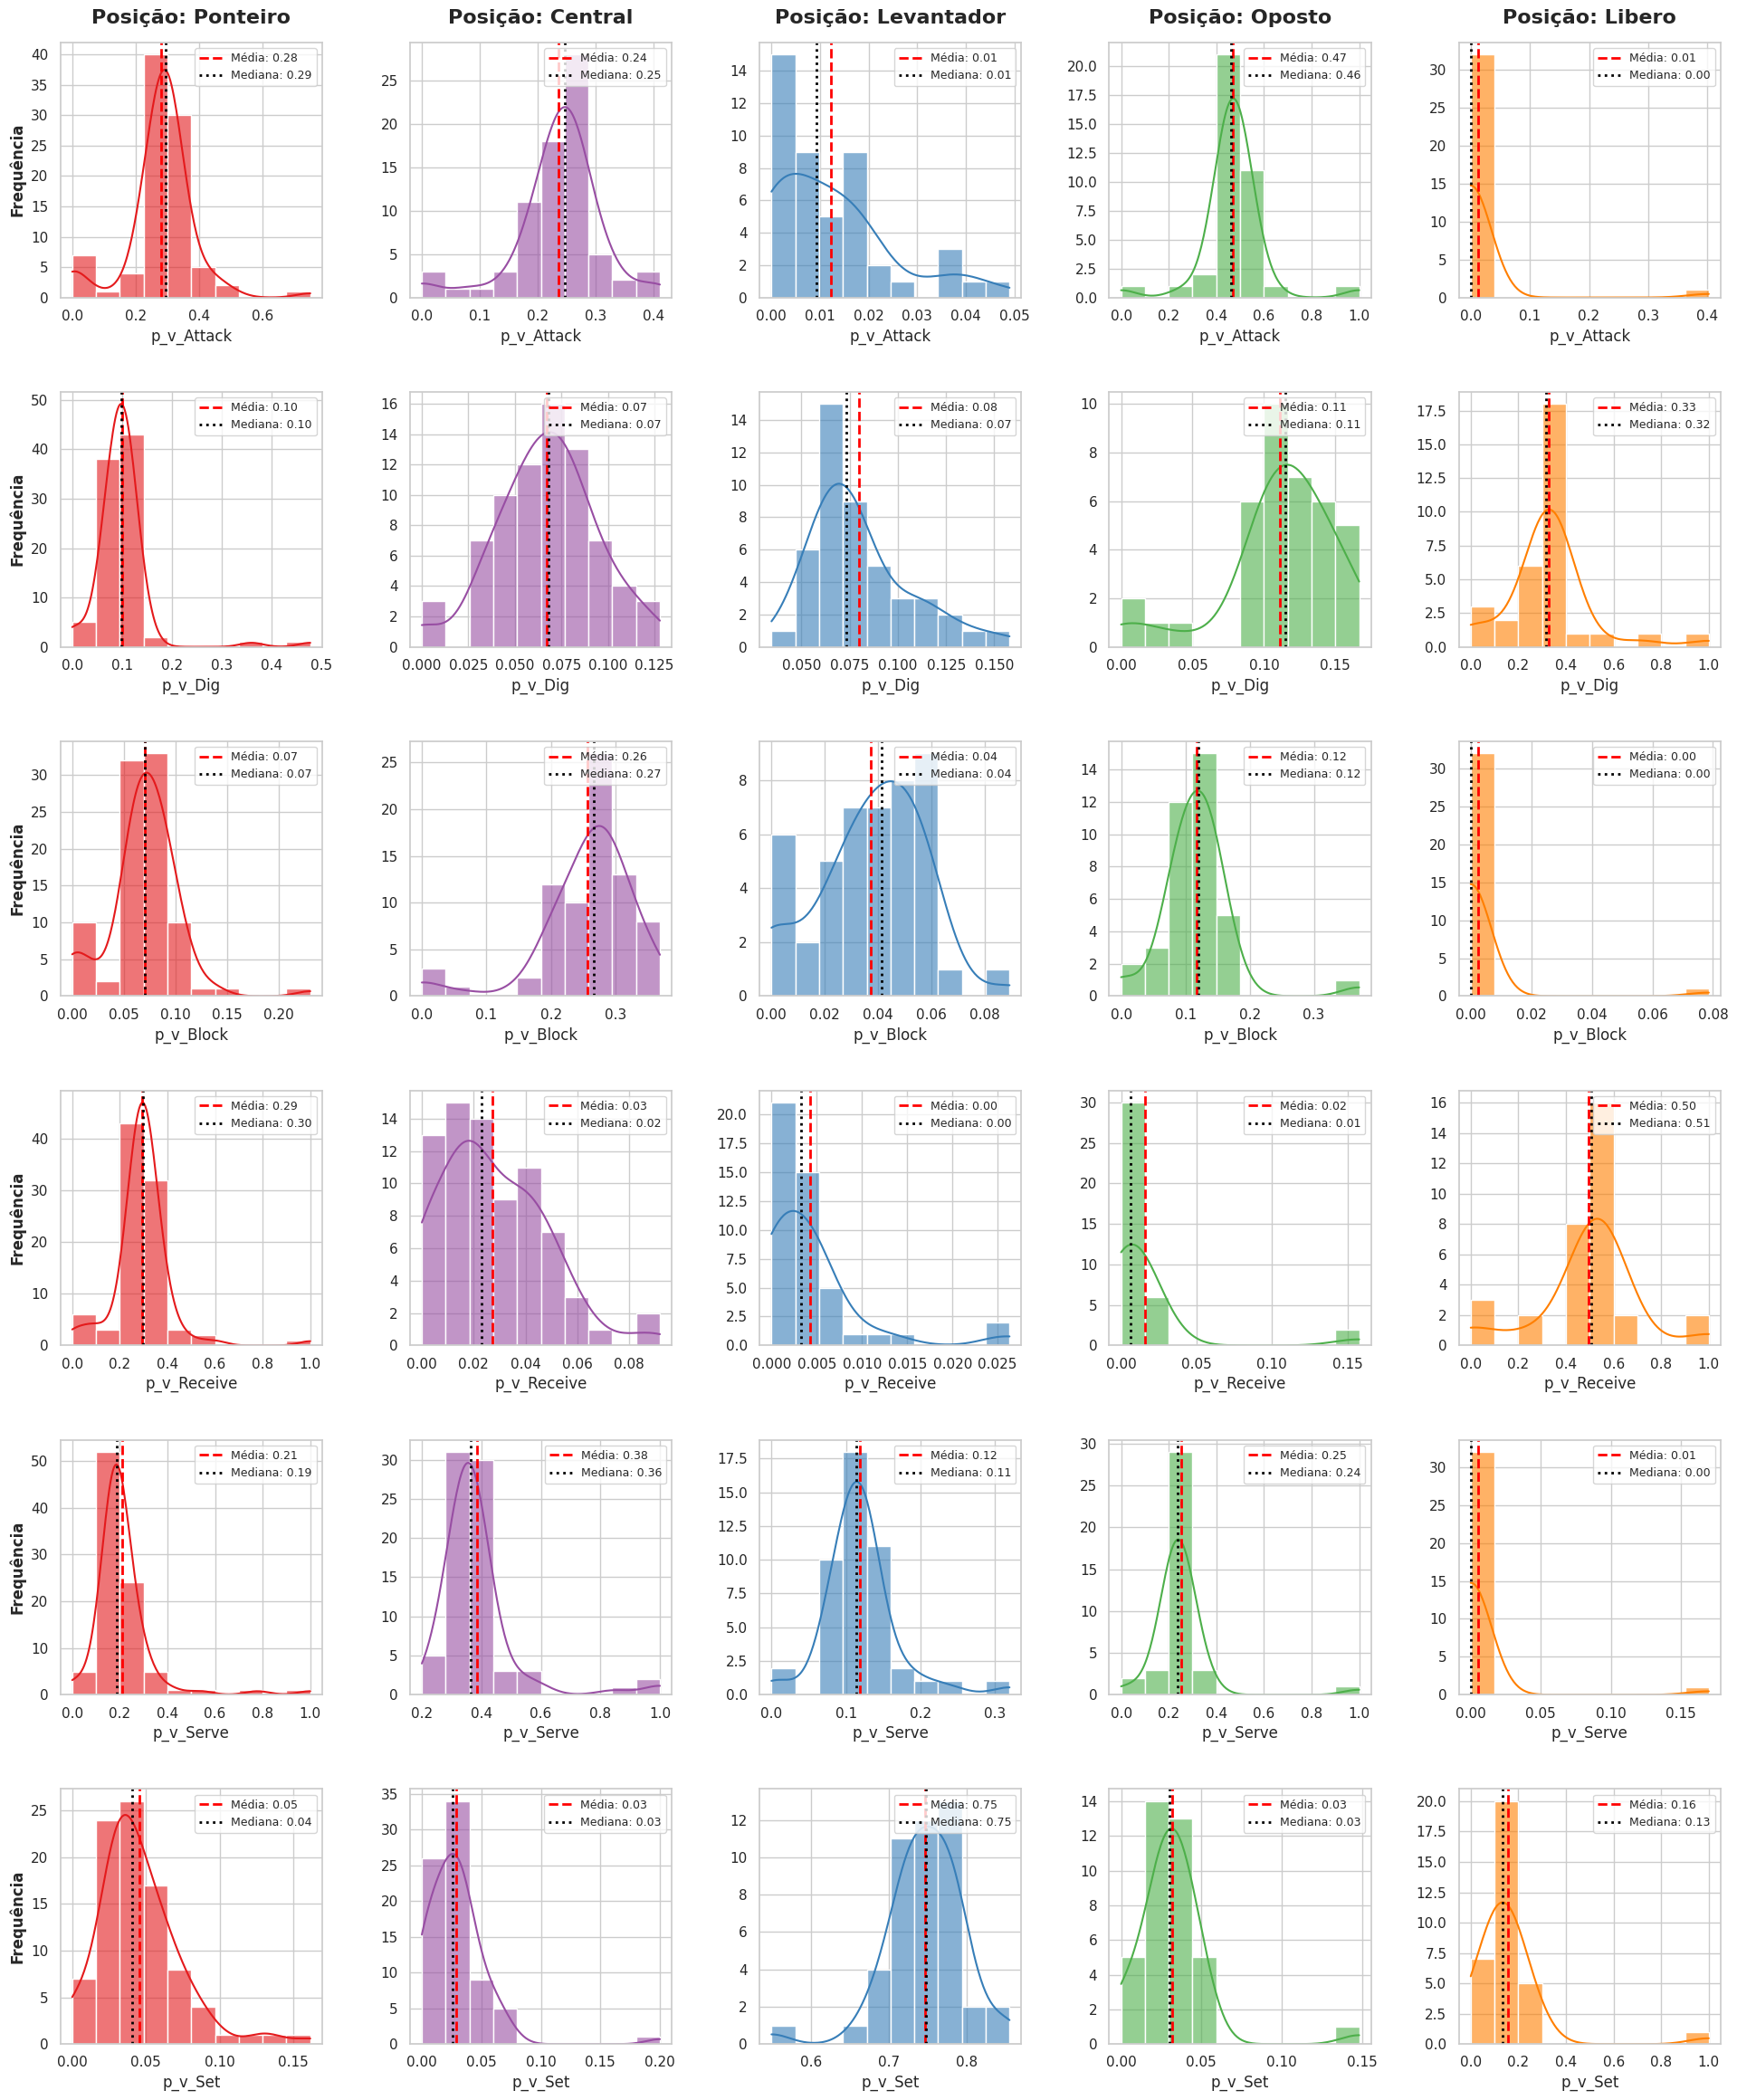

In [ ]:
# Optamos por manter as escalas dos eixos Y independentes por gráfico devido
# a ilegibilidade. Já no eixo X, o range é calculado sobre todas as posições do
# atributo, garantindo que a distribuição de cada posição seja comparável visualmente.
plot_matriz_atributos(df_final, cores_posicao, ordem)


> O efeito mais importante do feature engeenering que fizemos é justamente a redução do "viés do reservas" para as posições que de fato exercem aquele fundamento. Após o tratamento, como podemos ver no gráfico, essa assimetria se atenua, na qual as distribuições passam a se aproximar de formas mais simétricas e melhor interpretáveis.


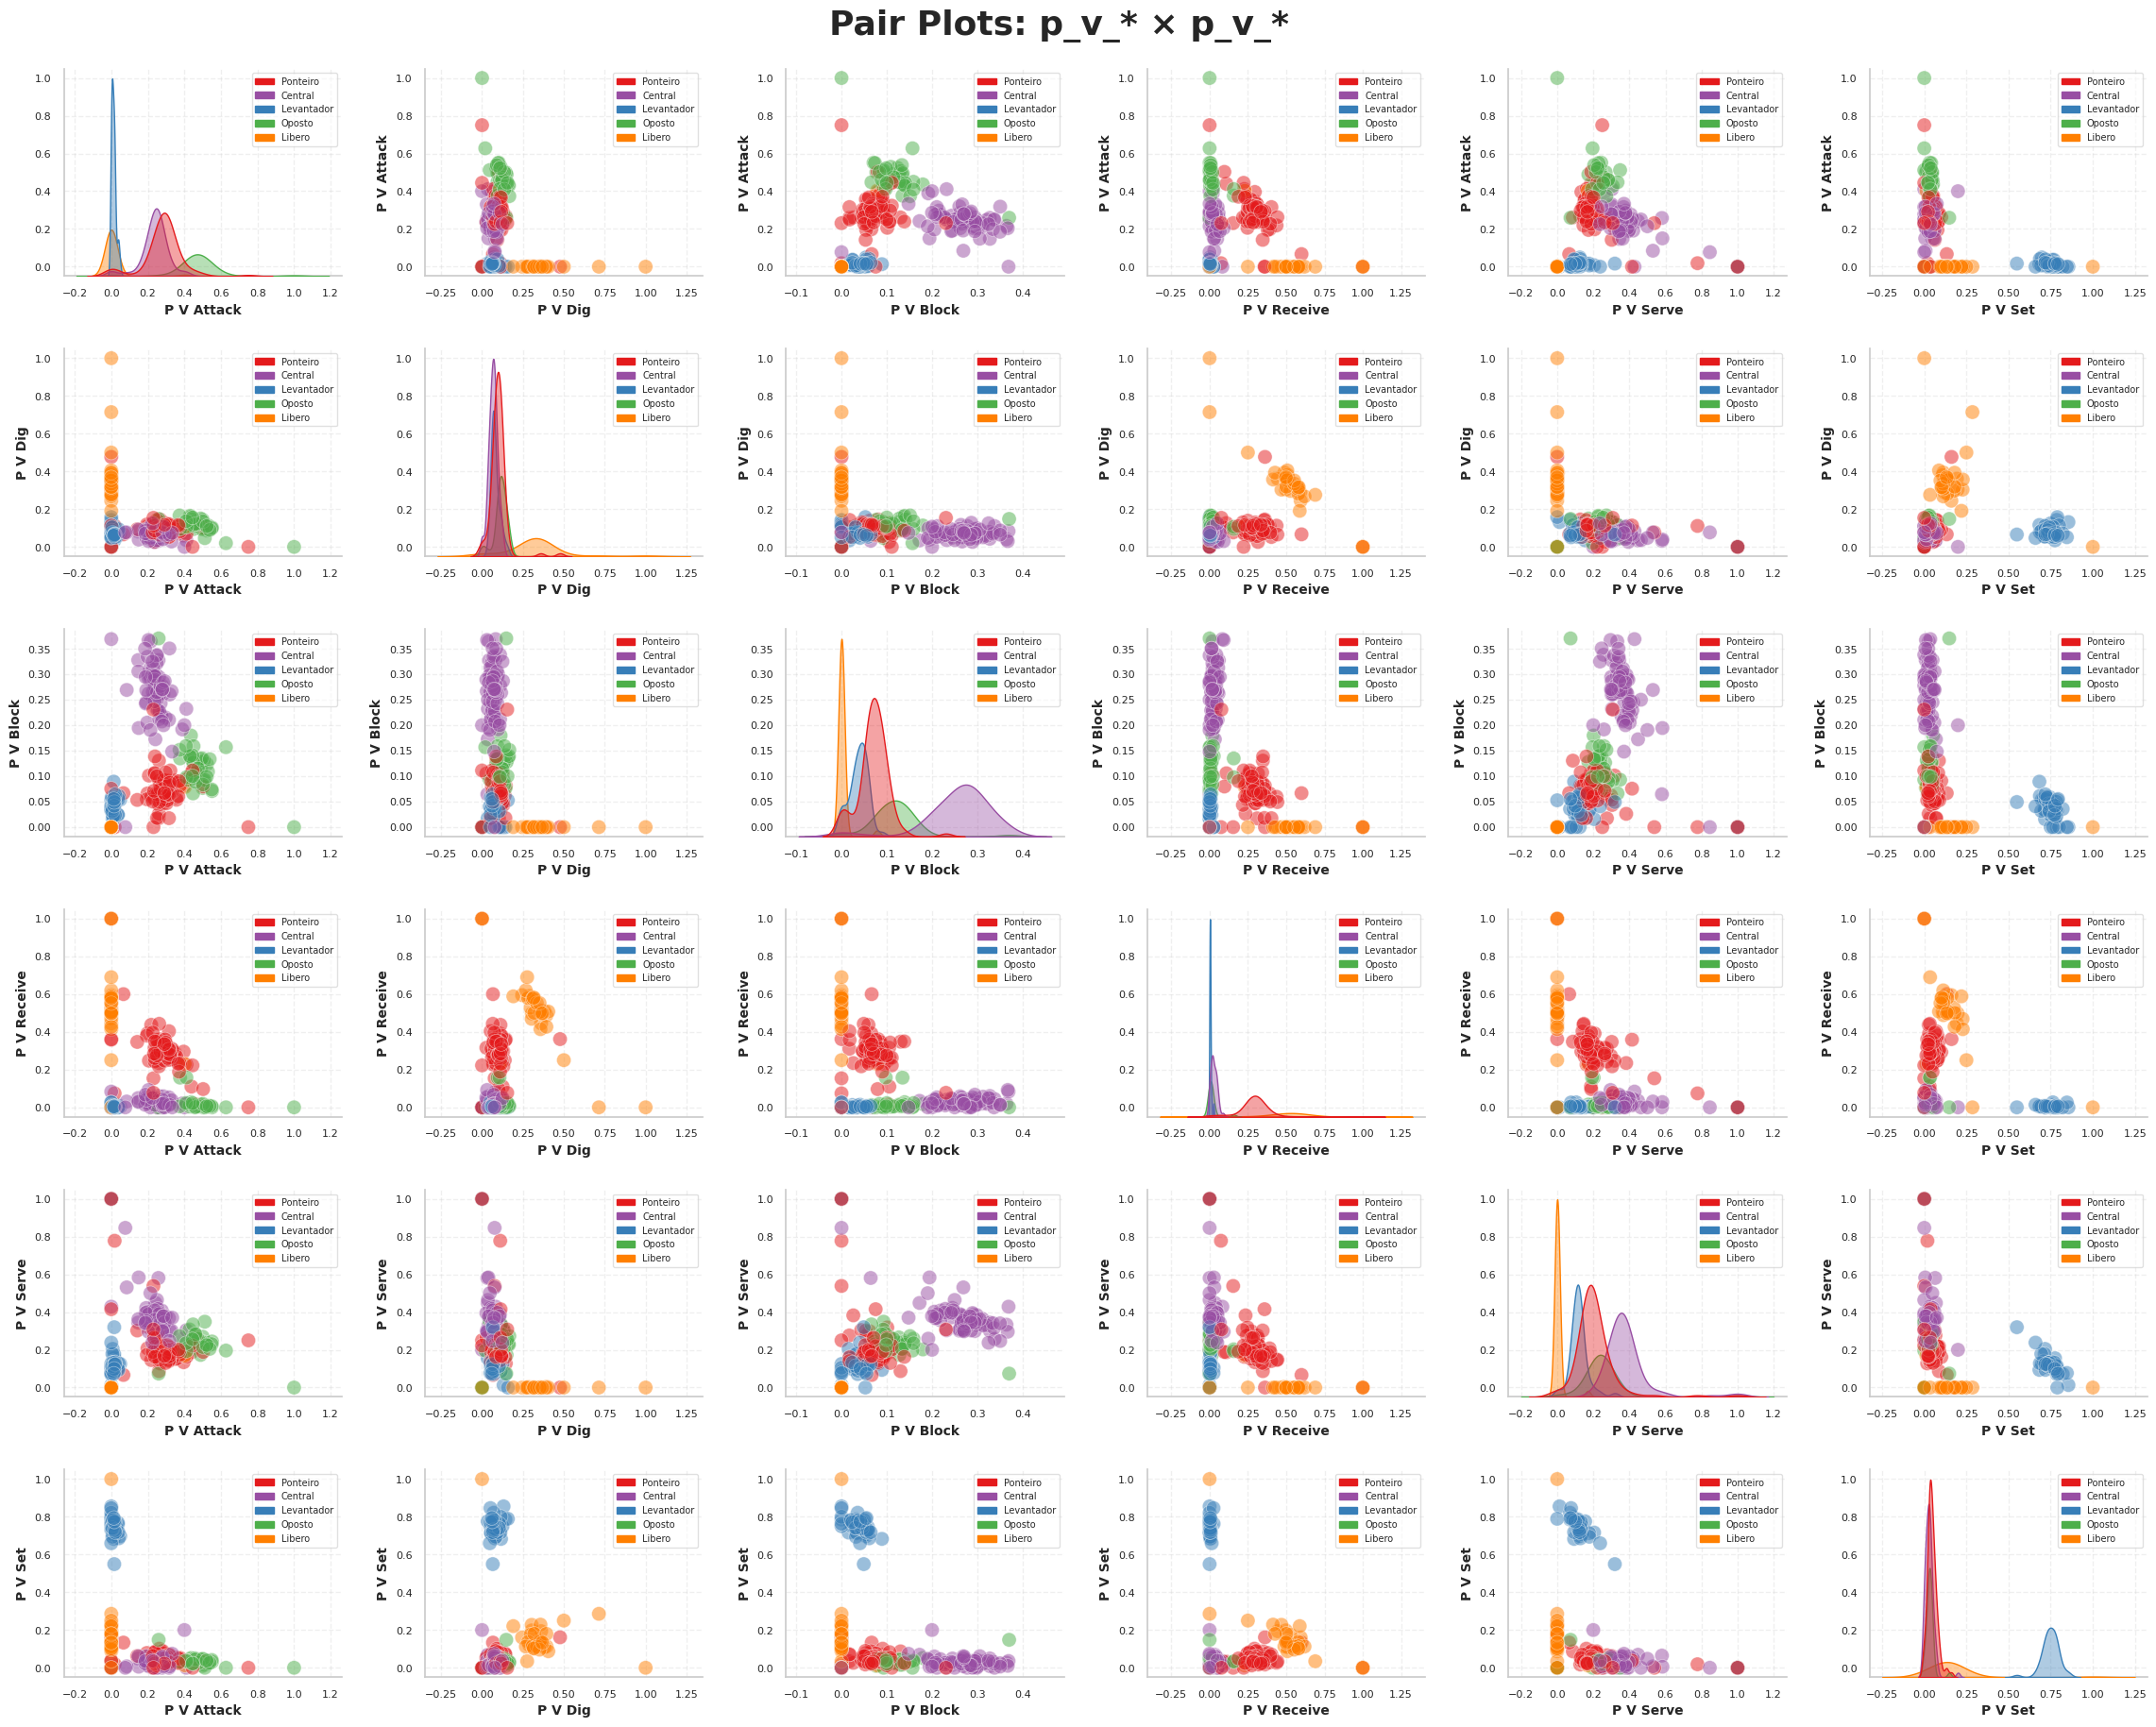

In [ ]:
 # Definindo variáveis de input da função
atributos = [col for col in df_final.columns if col.startswith(('p_v_'))]
pv_attrs = [a for a in atributos if a.startswith('p_v_')]
x_vars, y_vars, titulo = pv_attrs, pv_attrs, 'Pair Plots: p_v_* × p_v_*'

# Chamada a função da matriz de pairplots
build_pairplot(
    x_vars=x_vars,
    y_vars=y_vars,
    titulo=titulo,
    df=df_final,
    posicoes_ordem=ordem,
    cores_posicao=cores_posicao
)

> Os pairplots confirmam, a partir dos dados, a separação entre posições:

> 1. **Levantador (S):** em qualquer par que envolva `p_v_Set`, o Levantador se isola por completo. Seus valores de `p_v_Set` dominam o eixo (acima de 0.6), enquanto todas as demais posições colapsam próximas de zero nessa variável. É a posição com a separação mais limpa de todo o dataset.

> 2. **Líbero (L):** nos pares com `p_v_Receive` e `p_v_Dig`, ocupa uma região própria bem definida, com valores de recepção sistematicamente acima de 0.3 e defesa acima de 0.2. Nos pares com `p_v_Attack` ou `p_v_Block`, colapsa junto à origem, refletindo a proibição dessas ações para a posição.

> 3. **Ponteiro (OH):** os pares de `p_v_Receive` com `p_v_Attack` o posicionam numa região intermediária exclusiva, com participação simultânea em ambos os fundamentos. Essa dupla presença (ataque + recepção) é a assinatura do perfil híbrido que distingue o Ponteiro de todas as outras posições.

> 4. **Central (MB):** `p_v_Block` é o discriminador mais forte. O Central é o único perfil com volume de bloqueio expressivo (acima de 0.15), combinado com `p_v_Serve` elevado. Essa combinação o separa de Ponteiros e Opostos com clareza nos pares `p_v_Block × p_v_Serve` e `p_v_Block × p_v_Attack`.

> 5. **Oposto (O):** é a posição mais difícil de isolar visualmente. Apresenta `p_v_Attack` alto (similar ao Ponteiro), mas `p_v_Receive` próximo de zero (diferente do Ponteiro). O par `p_v_Attack × p_v_Receive` é o que melhor ajuda a separá-lo, porém ainda há sobreposição relevante com Ponteiros e Centrais, sendo assim, um desafio concreto para os algoritmos de clusterização.

## 4.5 Síntese da análise exploratória

A análise exploratória revelou padrões fundamentais sobre o comportamento estatístico das cinco posições do voleibol masculino de alto nível, fornecendo direcionamentos claros para as etapas de pré-processamento e seleção de algoritmos de clusterização.

---

### Balanceamento entre as posições

As cinco posições apresentam um desequilíbrio moderado de representatividade: Ponteiros são a maioria, com 94 atletas (32,3%), e Líberos a minoria, com 35 (12,0%), gerando uma proporção de 2,7× entre elas. Esse comportamento é estrutural e natural do voleibol, reflexo de uma escalação padrão que exige dois Ponteiros e dois Centrais em quadra contra apenas um Líbero por jogo. Esse desbalanceamento tem impacto direto na clusterização: o K-Means tende a formar clusters de tamanho similar, o que pode prejudicar a recuperação de posições minoritárias como o Líbero; o DBSCAN, por sua vez, pode interpretar posições numerosas e difusas (como Ponteiro) como regiões de baixa densidade. Ambos os efeitos são monitorados nas seções 8 e 9.

---

### Valores ausentes e zeros estruturais

O conjunto de dados final (`df_final`) não apresenta valores ausentes: nenhuma das seis variáveis `p_v_*` retém valores nulos. No entanto, a EDA revelou uma forte presença de zeros estruturais. Essas ausências não representam falhas de coleta, mas decorrem das próprias regras e da dinâmica tática do voleibol, que restringem ou direcionam certas ações a posições específicas:

- **Líberos:** valores zerados em `p_v_Attack` (97%), `p_v_Block` (97%) e `p_v_Serve` (91%) dos registros, refletindo a proibição regulamentar dessas ações para a posição.
- **Levantadores:** baixo volume de recepção, com `p_v_Receive` zerado em 33% dos casos, já que o sistema tático os libera dessa função para ficarem disponíveis para o levantamento.
- **Opostos:** lógica semelhante, com `p_v_Receive` zerado em 19% dos registros, priorizando sua especialização ofensiva em detrimento da recepção.

É importante ressaltar que essa análise foi realizada após a eliminação de perfis vazios. Atletas com `Total_Geral = 0` (sem nenhuma ação registrada) foram removidos na etapa de tratamento prévio, antes do cálculo das proporções. Portanto, os zeros identificados são puramente estruturais (intrínsecos à função de cada jogador em quadra) e não resíduos de baixa participação ou de dados corrompidos.

Esses zeros são altamente informativos para os algoritmos de clusterização: um atleta com `p_v_Attack ≈ 0` e `p_v_Block ≈ 0` carrega uma assinatura geométrica forte que o posiciona naturalmente perto de outros Líberos no espaço de features, facilitando a formação de clusters coesos mesmo sem acesso ao rótulo de posição.

---

### Distribuição das variáveis e implicações para escala

Todas as seis features (`p_v_*`) são proporções definidas no intervalo **[0, 1]**, o que elimina qualquer disparidade de escala intrínseca. Ainda assim, a aplicação de `StandardScaler` é justificada para os três algoritmos de clusterização utilizados neste trabalho (K-Means, DBSCAN e HCA com linkage `ward`), todos baseados em distância euclidiana, por dois motivos:

1. **Variância condicional desigual:** `p_v_Set` apresenta uma distribuição fortemente bimodal, quase zero para todas as posições exceto Levantadores (média 0,747). Essa concentração pode dominar o cálculo de distância euclidiana mesmo dentro do intervalo [0,1], fazendo com que `p_v_Set` sozinha determine a formação dos clusters.
2. **Centramento:** o `StandardScaler` garante que nenhuma feature domine as distâncias por ter maior variância absoluta, permitindo que todas as seis variáveis contribuam proporcionalmente na formação dos agrupamentos.

---

### Padrões identificados e estratégia de modelagem

Os pairplots e as médias por posição confirmam separações bem delineadas pelas regras do esporte:

| Posição | Discriminador primário | Discriminador secundário |
|:---|:---|:---|
| **Levantador** | `p_v_Set` muito alto (média 0,747) | Único com esse padrão, isolamento quase perfeito |
| **Líbero** | `p_v_Receive` muito alto (média 0,495) | `p_v_Attack` ≈ 0 e `p_v_Block` ≈ 0 |
| **Ponteiro** | `p_v_Receive` elevado (média 0,293) + `p_v_Attack` moderado | Perfil híbrido ataque/recepção |
| **Central** | `p_v_Block` alto (média 0,255) | `p_v_Serve` elevado (média 0,384) |
| **Oposto** | Posição residual: ataque alto, sem recepção, `p_v_Block` moderado | `p_v_Block` (média 0,121) distingue do Central |

Essa separação baseada em discriminadores fortes e quase exclusivos por posição é exatamente o tipo de estrutura que favorece algoritmos de clusterização. Ela sugere a existência de grupos compactos e razoavelmente bem separados no espaço de features, o que motiva diretamente o uso de K-Means, DBSCAN e HCA na seção 7.

# 5. Preparação dos dados para a clusterização

Diferente de problemas supervisionados, a clusterização não exige divisão treino/teste: como não há rótulo guiando o aprendizado, não existe risco de vazamento de informação entre conjuntos. O objetivo aqui é avaliar a estrutura intrínseca de **todo** o conjunto de dados disponível, por isso o `X` definido abaixo utiliza as 282 instâncias completas de `df_final`.

A coluna `Position` (`y`) é mantida separadamente, **fora de `X`**, e só será usada depois de os clusters serem formados, exclusivamente para calcular o ARI e auxiliar a interpretação visual dos resultados.

In [ ]:
# Define as features usadas na clusterização (X) e a posição real, mantida apenas para validação (y)
features = [col for col in df_final.columns if col.startswith('p_v_')]
X = df_final[features].copy()
y = df_final['Position'].copy()

print(f"Instâncias: {len(X)}")
print(f"Features:   {features}")

Instâncias: 282
Features:   ['p_v_Attack', 'p_v_Dig', 'p_v_Block', 'p_v_Receive', 'p_v_Serve', 'p_v_Set']


# 6. Pré-processamento

## 6.1 Padronização das features (StandardScaler)

As features `p_v_*` estão no intervalo $[0, 1]$, mas possuem variâncias muito distintas. Por exemplo, `p_v_Set` ($\sigma \approx 0{,}27$) dominaria as métricas de distância se não fosse padronizada. O `StandardScaler` corrige essa distorção, centrando cada variável em média zero e desvio padrão unitário, garantindo que todas contribuam proporcionalmente no cálculo das distâncias.

In [ ]:
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X)

print("Parâmetros do StandardScaler (ajustado sobre as 282 instâncias):")
print(f"{'Feature':<18} {'Média':>10} {'Desvio Padrão':>15}")
print("─" * 45)
for feat, mean, std in zip(features, scaler.mean_, scaler.scale_):
    print(f"{feat:<18} {mean:>10.4f} {std:>15.4f}")

Parâmetros do StandardScaler (ajustado sobre as 282 instâncias):
Feature                 Média   Desvio Padrão
─────────────────────────────────────────────
p_v_Attack             0.2189          0.1725
p_v_Dig                0.1159          0.1070
p_v_Block              0.1128          0.1038
p_v_Receive            0.1618          0.2012
p_v_Serve              0.2238          0.1652
p_v_Set                0.1669          0.2669


# 7. K-Means

O K-Means itera entre duas etapas até convergência: (1) atribuir cada ponto ao centroide mais próximo e (2) recalcular cada centroide como a média dos pontos do seu cluster. O resultado são `k` grupos esféricos centrados em torno de médias.

O algoritmo foi escolhido por permitir fixar `k=5` diretamente, testando a Hipótese 1 de forma objetiva. A EDA (seção 4.5) identificou grupos compactos e com discriminadores fortes por posição, que é o tipo de estrutura que o K-Means consegue capturar bem.

Ao longo desta seção, vamos desde a execução com `k=5` até a análise de sensibilidade ao número de clusters, verificando não só o desempenho do modelo no nosso dataset, mas também onde ele acerta, onde erra e o que isso revela sobre a estrutura tática dos dados.

## 7.1 Baseline (k=5, configuração padrão)

In [ ]:
# ── K-Means com k=5 fixo, sem validação prévia da estrutura ─────────────────
km_base = KMeans(n_clusters=5, random_state=SEED, n_init=20)
labels_km_base = km_base.fit_predict(X_scaled_all)

ari_km_base = adjusted_rand_score(y, labels_km_base)
sil_km_base = silhouette_score(X_scaled_all, labels_km_base)

print(f"K-Means (k=5) — avaliação contra as posições reais:")
print(f"  ARI (Adjusted Rand Index) : {ari_km_base:.4f}")
print(f"  Silhouette Score          : {sil_km_base:.4f}")

# ── Centroides — perfis táticos recuperados ─────────────────────────────────
centroides_base = pd.DataFrame(
    scaler.inverse_transform(km_base.cluster_centers_),
    columns=features
).round(3)

df_km_base = X.copy()
df_km_base['cluster'] = labels_km_base
df_km_base['posicao_real'] = y.values
mapa_cluster_base = df_km_base.groupby('cluster')['posicao_real'].agg(lambda s: s.value_counts().index[0])
centroides_base.index = [f"Cluster {i} (≈{mapa_cluster_base[i]})" for i in centroides_base.index]

print("\nCentroides K-Means (valores originais p_v_*):")
display(centroides_base.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))


K-Means (k=5) — avaliação contra as posições reais:
  ARI (Adjusted Rand Index) : 0.7140
  Silhouette Score          : 0.5759

Centroides K-Means (valores originais p_v_*):


,p_v_Attack,p_v_Dig,p_v_Block,p_v_Receive,p_v_Serve,p_v_Set
Cluster 0 (≈Ponteiro),0.358,0.100,0.085,0.205,0.213,0.039
Cluster 1 (≈Levantador),0.012,0.078,0.036,0.004,0.117,0.752
Cluster 2 (≈Libero),0.002,0.331,0.002,0.531,0.002,0.132
Cluster 3 (≈Central),0.245,0.071,0.268,0.029,0.357,0.031
Cluster 4 (≈Central),0.016,0.031,0.000,0.012,0.937,0.003


### Análise do baseline (k=5)

Com `k=5` fixo, o K-Means atinge **ARI = 0.7140** e **Silhouette = 0.5759**, cumprindo a meta da Hipótese 1 (ARI > 0,70) por margem estreita. Os centroides, porém, revelam que esse resultado esconde um desencontro entre os clusters formados e as cinco posições reais:

- **Cluster 1 ≈ Levantador:** isolamento perfeito, com `p_v_Set = 0.752` dominando o perfil e todas as demais ações baixas. É a posição recuperada com maior pureza, como previsto na EDA.
- **Cluster 2 ≈ Líbero:** também bem definido, com `p_v_Receive = 0.531` e `p_v_Dig = 0.331`, e ataque/bloqueio praticamente zerados (`p_v_Attack = 0.002`, `p_v_Block = 0.002`), refletindo a proibição regulamentar dessas ações.
- **Cluster 0 ≈ Ponteiro:** perfil híbrido esperado, com `p_v_Attack = 0.358` combinado a `p_v_Receive = 0.205`. É aqui, porém, que reside o problema: sem um cluster próprio, o **Oposto acaba absorvido por este cluster**, já que compartilha com o Ponteiro o alto volume de ataque.
- **Clusters 3 e 4 ≈ Central (dividido em dois):** em vez de isolar o Oposto, o algoritmo "gasta" um dos cinco clusters fragmentando o Central. O Cluster 3 é o Central clássico (`p_v_Block = 0.268`, `p_v_Serve = 0.357`), enquanto o Cluster 4 é um perfil extremo de sacador (`p_v_Serve = 0.937`) com todas as outras ações próximas de zero — um subgrupo minúsculo e provável outlier.

**O diagnóstico central do baseline:** o K-Means com `k=5` não reproduz as cinco posições oficiais. Ele recupera com fidelidade Levantador, Líbero e Ponteiro, mas troca o Oposto (que colapsa dentro do Ponteiro) por uma segunda fatia de Central. Ou seja, o ARI de 0.7140 é atingido *apesar* de o quinto cluster não corresponder a uma quinta posição real.

## 7.2 Método do Cotovelo e Silhouette Score

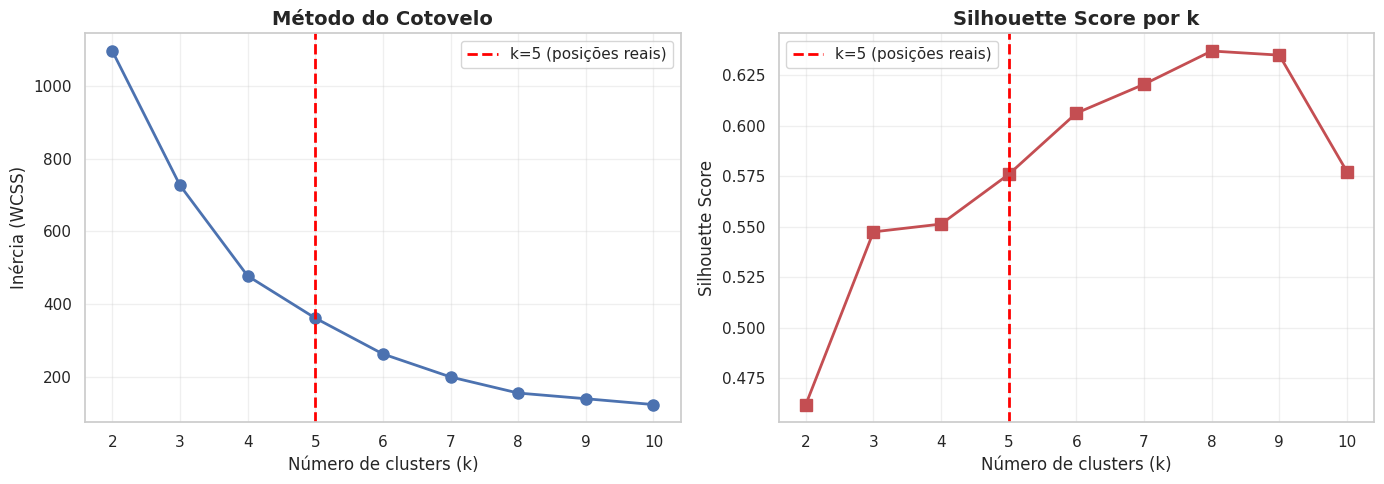

Silhouette com k=5: 0.5759


In [ ]:
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labs = km.fit_predict(X_scaled_all)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_all, labs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', lw=2, ms=8)
axes[0].axvline(x=5, color='red', ls='--', lw=2, label='k=5 (posições reais)')
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inércia (WCSS)', fontsize=12)
axes[0].set_title('Método do Cotovelo', fontsize=14, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(k_range, sil_scores, 'rs-', lw=2, ms=8)
axes[1].axvline(x=5, color='red', ls='--', lw=2, label='k=5 (posições reais)')
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score por k', fontsize=14, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Silhouette com k=5: {sil_scores[3]:.4f}")

### Análise do plot

**Método do Cotovelo:** Verificamos que não há um cotovelo nítido em `k=5`. A inércia cai de forma suave e contínua até `k=8`, sem um ponto de inflexão claro que justifique `k=5` pela geometria dos dados. Isso significa que adicionar um sexto, sétimo ou oitavo cluster ainda reduz significativamente a variância interna dos grupos, ou seja, os dados possuem subdivisões naturais além das 5 posições táticas oficiais.

**Silhouette Score:** o pico ocorre em `k=8` (≈0.638) e `k=9` (≈0.636), ambos acima do valor em `k=5` (0.576). Isso indica que, do ponto de vista puramente geométrico, os dados se organizam melhor em 8 a 9 grupos do que em 5. Esse resultado é coerente com o achado da seção anterior, onde o K-Means já fragmentou Central em dois clusters distintos com `k=5`.

Na próxima subseção, avaliamos o K-Means para `k` de 3 a 10 usando o ARI contra as posições reais, para identificar em qual granularidade o algoritmo melhor recupera a estrutura tática conhecida.

## 7.3 Sensibilidade a k (k=3..10)

In [ ]:
# ── Sensibilidade do K-Means a k (k=3..10) ──────────────────────────────────
resultados_km_k = {}

for k in range(3, 11):
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labs_k = km_k.fit_predict(X_scaled_all)
    ari_k = adjusted_rand_score(y, labs_k)
    sil_k = silhouette_score(X_scaled_all, labs_k)
    resultados_km_k[k] = {'ARI': ari_k, 'Silhouette': sil_k, 'labels': labs_k, 'modelo': km_k}
    print(f"k={k}:  ARI={ari_k:.4f}  |  Silhouette={sil_k:.4f}")

melhor_k_ari = max(resultados_km_k, key=lambda k: resultados_km_k[k]['ARI'])
print(f"\nMelhor k por ARI: {melhor_k_ari}  (ARI={resultados_km_k[melhor_k_ari]['ARI']:.4f})")

# ── Centroides e distribuição do melhor k ───────────────────────────────────
km_best = resultados_km_k[melhor_k_ari]['modelo']
labels_km_best = resultados_km_k[melhor_k_ari]['labels']

centroides_best = pd.DataFrame(
    scaler.inverse_transform(km_best.cluster_centers_),
    columns=features
).round(3)

df_km_best = X.copy()
df_km_best['cluster'] = labels_km_best
df_km_best['posicao_real'] = y.values
mapa_cluster_best = df_km_best.groupby('cluster')['posicao_real'].agg(lambda s: s.value_counts().index[0])
contagem_clusters = pd.Series(labels_km_best).value_counts().sort_index()
centroides_best.index = [f"Cluster {i} (≈{mapa_cluster_best[i]}, n={contagem_clusters[i]})" for i in centroides_best.index]

print(f"\nK-Means (k={melhor_k_ari}) — avaliação contra as posições reais:")
print(f"  ARI (Adjusted Rand Index) : {resultados_km_k[melhor_k_ari]['ARI']:.4f}")
print(f"  Silhouette Score          : {resultados_km_k[melhor_k_ari]['Silhouette']:.4f}")

print(f"\nCentroides K-Means (valores originais p_v_*):")
display(centroides_best.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))

k=3:  ARI=0.3575  |  Silhouette=0.5474
k=4:  ARI=0.6947  |  Silhouette=0.5513
k=5:  ARI=0.7140  |  Silhouette=0.5759
k=6:  ARI=0.8234  |  Silhouette=0.6062
k=7:  ARI=0.8461  |  Silhouette=0.6204
k=8:  ARI=0.8374  |  Silhouette=0.6369
k=9:  ARI=0.8437  |  Silhouette=0.6349
k=10:  ARI=0.7529  |  Silhouette=0.5772

Melhor k por ARI: 7  (ARI=0.8461)

K-Means (k=7) — avaliação contra as posições reais:
  ARI (Adjusted Rand Index) : 0.8461
  Silhouette Score          : 0.6204

Centroides K-Means (valores originais p_v_*):


,p_v_Attack,p_v_Dig,p_v_Block,p_v_Receive,p_v_Serve,p_v_Set
"Cluster 0 (≈Central, n=71)",0.239,0.071,0.272,0.029,0.360,0.028
"Cluster 1 (≈Levantador, n=47)",0.012,0.078,0.036,0.004,0.117,0.752
"Cluster 2 (≈Ponteiro, n=81)",0.287,0.094,0.072,0.302,0.200,0.046
"Cluster 3 (≈Oposto, n=43)",0.486,0.107,0.115,0.020,0.239,0.034
"Cluster 4 (≈Libero, n=32)",0.000,0.306,0.000,0.562,0.000,0.131
"Cluster 5 (≈Central, n=6)",0.016,0.031,0.000,0.012,0.937,0.003
"Cluster 6 (≈Libero, n=2)",0.000,0.857,0.000,0.000,0.000,0.143


### Análise da sensibilidade

Os ganhos de ARI não são graduais, eles vêm em dois saltos localizados:

| Transição | Δ ARI | O que acontece |
|---|---|---|
| k=3 → k=4 | +0.337 | Maior salto: posições gravemente fundidas são separadas |
| k=4 → k=5 | +0.019 | Ganho quase nulo: o 5º cluster fragmenta Central em vez de isolar Oposto |
| k=5 → k=6 | +0.109 | Segundo maior salto: Oposto provavelmente ganha cluster próprio |
| k=6 → k=7 | +0.023 | Ganho pequeno, positivo |
| k=7 → k=8 | −0.009 | Estabiliza |
| k=8 → k=9 | +0.006 | Estabiliza |
| k=9 → k=10 | −0.091 | Queda abrupta: fragmentação excessiva |

O ganho quase nulo de `k=4 → k=5` (+0.019) confirma numericamente o que a análise dos centroides já havia mostrado: o 5º cluster não resolve a ausência do Oposto, ele é "gasto" fragmentando Central em dois subgrupos. O salto expressivo de `k=5 → k=6` (+0.109) indica que é nessa transição que o Oposto provavelmente ganha um cluster próprio, corrigindo a principal fonte de erro identificada em `k=5`.

O melhor ARI ocorre em `k=7` (0.8461) e o melhor Silhouette em `k=8` (0.6369). Essa convergência para a faixa de 7 a 9 clusters reforça o que o Cotovelo e o Silhouette por k (seção 7.2) já haviam indicado: os dados possuem subdivisões naturais além das 5 posições oficiais.

**Os centroides de `k=7` revelam como esses clusters extras se distribuem:**
- **Oposto isolado (Cluster 3, n=43):** `p_v_Attack=0.486` e `p_v_Receive≈0`, finalmente separado do Ponteiro. Era a principal lacuna em `k=5`.
- **Central dividido em dois (Clusters 0 e 5):** perfil clássico de bloqueio/saque com 71 atletas (Cluster 0) vs. sacador especialista com `p_v_Serve=0.937` e apenas 6 atletas (Cluster 5).
- **Líbero dividido em dois (Clusters 4 e 6):** Líbero clássico de recepção e defesa com 32 atletas (Cluster 4) vs. perfil de especialista puro em defesa (`Dig=0.857`, `Receive=0.000`) com apenas 2 atletas (Cluster 6).

O tamanho dos Clusters 5 (n=6) e 6 (n=2) confirma que se tratam de perfis extremos, provavelmente outliers isolados pelo algoritmo. Seus centroides são dominados por uma única feature acima de 0.85, com todas as demais próximas de zero, o que reforça essa interpretação.

# 8. DBSCAN

O DBSCAN identifica clusters como regiões de alta densidade separadas por regiões esparsas. Diferente do K-Means, não exige definir o número de clusters a priori e marca pontos em regiões de baixa densidade como **ruído** (label `−1`). Os dois hiperparâmetros principais são `eps` (raio da vizinhança) e `min_samples` (mínimo de pontos para formar um core point).

O algoritmo foi escolhido para testar a Hipótese 2: como as densidades variam entre posições (Ponteiro é numeroso e difuso, Líbero é compacto e minoritário), é plausível que o DBSCAN tenha dificuldade em isolar exatamente 5 clusters sem ruído. Além disso, por não assumir formato esférico, ele pode revelar estruturas que o K-Means não captura.

Ao longo desta seção, executamos o DBSCAN com os hiperparâmetros padrão do scikit-learn e, em seguida, realizamos uma busca em grade sobre `eps` e `min_samples` para avaliar a sensibilidade do algoritmo a essas escolhas.

## 8.1 Baseline (eps=0.5, min_samples=5)

In [ ]:
db_base = DBSCAN(eps=0.5, min_samples=5)
labels_db_base = db_base.fit_predict(X_scaled_all)

n_clust_base = len(set(labels_db_base)) - (1 if -1 in labels_db_base else 0)
n_ruido_base = (labels_db_base == -1).sum()
ari_db_base  = adjusted_rand_score(y, labels_db_base)
sil_db_base  = silhouette_score(X_scaled_all, labels_db_base) if n_clust_base > 1 else 0.0

print(f"DBSCAN (default: eps=0.5, min_samples=5):")
print(f"  Clusters encontrados : {n_clust_base}")
print(f"  Ruído (atletas)      : {n_ruido_base} de {len(X)} ({n_ruido_base/len(X)*100:.1f}%)")
print(f"  ARI                  : {ari_db_base:.4f}")
print(f"  Silhouette           : {sil_db_base:.4f}")

DBSCAN (default: eps=0.5, min_samples=5):
  Clusters encontrados : 5
  Ruído (atletas)      : 47 de 282 (16.7%)
  ARI                  : 0.6909
  Silhouette           : 0.5025


### Análise dos resultados

Os hiperparâmetros padrão do scikit-learn (`eps=0.5`, `min_samples=5`) encontram exatamente 5 clusters, mas o ARI de 0.6909 fica abaixo da meta de 0,70 por margem pequena (−0.009). O Silhouette de 0.5025 também é inferior ao obtido pelo K-Means com `k=5` (0.5759), indicando clusters menos coesos e pior separados.

Além disso, 47 dos 282 atletas (16,7%) foram classificados como ruído, um custo que o K-Means não tem, já que classifica 100% dos pontos. Isso significa que quase 1 em cada 6 atletas ficou sem agrupamento algum.

Mesmo no cenário em que o DBSCAN "acerta" o número de clusters, ele apresenta os dois sintomas previstos pela Hipótese 2: ARI inferior ao K-Means e descarte de uma fração significativa dos dados como ruído.

## 8.2 Busca de hiperparâmetros (eps × min_samples)

In [ ]:
eps_vals = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
ms_vals  = [3, 5]

resultados_dbscan = []

print(f"{'eps':>5}  {'min_s':>5}  {'n_clust':>8}  {'n_ruido':>8}  {'ARI':>8}  {'Silhouette':>11}")
print('─' * 55)

for eps in eps_vals:
    for ms in ms_vals:
        db = DBSCAN(eps=eps, min_samples=ms)
        labs = db.fit_predict(X_scaled_all)
        n_clust  = len(set(labs)) - (1 if -1 in labs else 0)
        n_ruido  = (labs == -1).sum()
        ari  = adjusted_rand_score(y, labs)
        sil  = silhouette_score(X_scaled_all, labs) if n_clust > 1 else 0.0
        resultados_dbscan.append({'eps': eps, 'min_samples': ms,
                                  'n_clusters': n_clust, 'n_ruido': n_ruido,
                                  'ARI': ari, 'Silhouette': sil, 'labels': labs})
        print(f"  {eps:>5.1f}  {ms:>5}  {n_clust:>8}  {n_ruido:>8}  {ari:>8.4f}  {sil:>11.4f}")

melhor_db = max(resultados_dbscan, key=lambda x: x['ARI'])
labels_db = melhor_db['labels']
ari_db    = melhor_db['ARI']
sil_db    = melhor_db['Silhouette']
print(f"\nMelhor DBSCAN: eps={melhor_db['eps']}, min_samples={melhor_db['min_samples']}")
print(f"  Clusters encontrados: {melhor_db['n_clusters']}  |  Ruído: {melhor_db['n_ruido']} atletas")
print(f"  ARI={ari_db:.4f}  |  Silhouette={sil_db:.4f}")

  eps  min_s   n_clust   n_ruido       ARI   Silhouette
───────────────────────────────────────────────────────
    0.3      3         9       101    0.3691       0.1765
    0.3      5         5       128    0.2767       0.1425
    0.5      3         7        39    0.7048       0.5339
    0.5      5         5        47    0.6909       0.5025
    0.7      3         6        23    0.6506       0.5529
    0.7      5         4        30    0.6469       0.5262
    1.0      3         5        13    0.3429       0.5616
    1.0      5         3        21    0.3401       0.5393
    1.5      3         4         4    0.2095       0.4526
    1.5      5         4         7    0.3502       0.5687
    2.0      3         3         3    0.2152       0.4293
    2.0      5         2         6    0.2153       0.4304

Melhor DBSCAN: eps=0.5, min_samples=3
  Clusters encontrados: 7  |  Ruído: 39 atletas
  ARI=0.7048  |  Silhouette=0.5339


### Análise da busca

A melhor configuração encontrada (`eps=0.5`, `min_samples=3`) produz 7 clusters com ARI de 0.7048, descartando 39 atletas como ruído. Novamente o número 7 aparece como ponto de maior coerência estrutural, o mesmo valor onde o K-Means atingiu seu pico de ARI (0.8461, seção 7.3). Dois algoritmos com lógicas completamente diferentes convergindo para a mesma granularidade reforça que os dados possuem subdivisões naturais além das 5 posições oficiais.

A grade revela um trade-off claro entre os extremos de `eps`:
- **`eps` pequeno (0.3):** fragmentação severa com 101 a 128 atletas em ruído (até 45% do dataset) e ARI abaixo de 0.37. O raio é pequeno demais para formar vizinhanças densas.
- **`eps` grande (1.0–2.0):** ruído quase zero, mas ARI desaba para 0.21–0.35. O raio funde múltiplas posições reais num único cluster.
- **Faixa útil restrita a `eps` ≈ 0.5–0.7**, onde ARI e ruído moderado coexistem.

Vale observar que Silhouette e ARI divergem com `eps` alto: em `eps=1.0` (ms=3), o Silhouette (0.5616) é maior do que na melhor configuração por ARI (0.5339), mas o ARI é muito pior (0.3429 vs. 0.7048). Isso acontece porque fundir várias posições num cluster grande produz pontos geometricamente "coesos" entre si, mas que na realidade pertencem a classes diferentes.

**Hipótese 2 confirmada.** Mesmo na melhor configuração da busca, o DBSCAN não recupera exatamente 5 clusters sem ruído. O algoritmo encontra estrutura tática real nos dados (ARI = 0.7048), mas com 7 clusters e 39 atletas descartados, confirmando a dificuldade prevista em casar a estrutura geométrica com as 5 posições oficiais.

# 9. Clusterização Hierárquica (HCA)

A clusterização hierárquica aglomerativa parte do princípio oposto ao K-Means: em vez de fixar `k` centroides, ela trata cada amostra inicialmente como seu próprio cluster e vai fundindo, a cada passo, o par de clusters mais similar entre si, até restar um único cluster. O resultado é uma árvore (**dendrograma**) que registra a distância de cada fusão, permitindo cortar a hierarquia no número de clusters desejado a qualquer momento, sem precisar re-treinar o modelo.

O algoritmo foi escolhido para testar a Hipótese 3: além de verificar se atinge ARI $> 0,70$ com `k=5`, o dendrograma permite visualizar diretamente a proximidade entre as posições, algo que K-Means e DBSCAN não expõem. A EDA (seção 4.5) sugere que Levantador e Líbero devem se separar do restante em alturas elevadas, enquanto Oposto, Ponteiro e Central devem se fundir em alturas mais baixas. Testamos quatro critérios de linkage (`ward`, `complete`, `average`, `single`), conforme recomendado pelo material de referência da disciplina, já que escolhas diferentes de critério de fusão levam a resultados distintos.

Ao longo desta seção, executamos a HCA com linkage `ward` e `k=5`, analisamos o dendrograma e, em seguida, realizamos uma busca sobre os diferentes critérios de linkage e números de clusters.

## 9.1 Dendrograma e baseline (linkage='ward', k=5)

O dendrograma abaixo mostra todas as fusões sucessivas feitas pela HCA sobre os 282 atletas (rotulados pela posição real apenas para leitura visual, o algoritmo não usa esse rótulo). A linha tracejada marca a altura de corte usada para obter exatamente 5 clusters, a configuração oficial testada pela Hipótese 3.

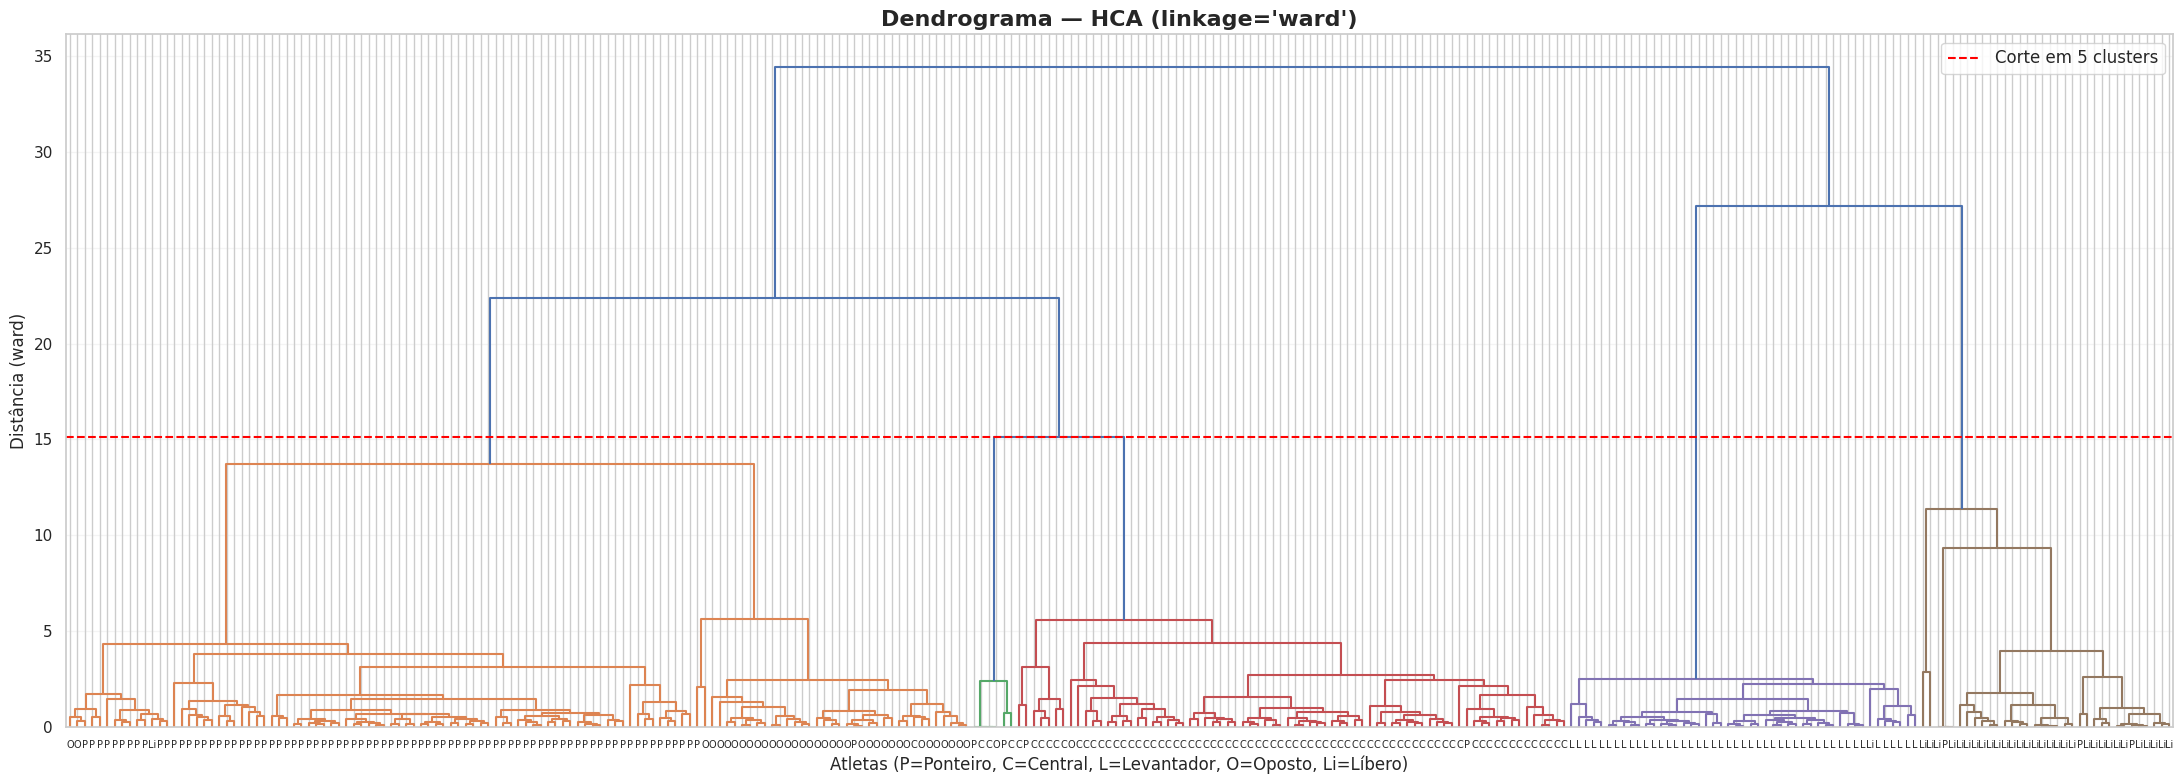

In [ ]:
Z = scipy_linkage(X_scaled_all, method='ward')

siglas = {'Ponteiro': 'P', 'Central': 'C', 'Levantador': 'L', 'Oposto': 'O', 'Libero': 'Li'}
y_siglas = y.map(siglas).values

plt.figure(figsize=(22, 8))
dendrogram(Z, labels=y_siglas, leaf_rotation=0, leaf_font_size=7, color_threshold=Z[-4, 2])
plt.axhline(y=Z[-4, 2], color='red', ls='--', lw=1.5, label='Corte em 5 clusters')
plt.title("Dendrograma — HCA (linkage='ward')", fontsize=16, fontweight='bold')
plt.xlabel('Atletas (P=Ponteiro, C=Central, L=Levantador, O=Oposto, Li=Líbero)', fontsize=12)
plt.ylabel('Distância (ward)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

> **O dendrograma expõe visualmente por que o corte em `k=5` erra.** O grande bloco laranja à esquerda contém Ponteiros e Opostos misturados num único ramo, que só se separa internamente em alturas muito baixas (abaixo de 5). Isso significa que, na escala de distância em que o corte de 5 clusters opera (≈ 15), esses dois grupos são indistinguíveis para o algoritmo. Enquanto isso, o pequeno bloco verde no centro, com apenas 6 atletas, consome um dos 5 cortes disponíveis, correspondendo ao subgrupo de sacador especialista já identificado nas seções anteriores. Em resumo, o corte em `k=5` "gasta" um cluster inteiro com 6 possíveis outliers em vez de usá-lo para separar Oposto de Ponteiro, que é onde o erro mais custa ao ARI.

In [ ]:
hca_base = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_hca_base = hca_base.fit_predict(X_scaled_all)

ari_hca_base = adjusted_rand_score(y, labels_hca_base)
sil_hca_base = silhouette_score(X_scaled_all, labels_hca_base)

print(f"HCA (linkage=ward, n_clusters=5) — avaliação contra os rótulos reais:")
print(f"  ARI (Adjusted Rand Index) : {ari_hca_base:.4f}")
print(f"  Silhouette Score          : {sil_hca_base:.4f}")

# Perfis médios por cluster (a HCA não calcula centroides nativamente, como o K-Means)
df_hca_base = X.copy()
df_hca_base['cluster'] = labels_hca_base
df_hca_base['posicao_real'] = y.values
perfis_hca_base = df_hca_base.groupby('cluster')[features].mean().round(3)
mapa_cluster_hca = df_hca_base.groupby('cluster')['posicao_real'].agg(lambda s: s.value_counts().index[0])
perfis_hca_base.index = [f"Cluster {i} (≈{mapa_cluster_hca[i]})" for i in perfis_hca_base.index]

print("\nPerfil médio por cluster (valores originais p_v_*):")
display(perfis_hca_base.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))


HCA (linkage=ward, n_clusters=5) — avaliação contra os rótulos reais:
  ARI (Adjusted Rand Index) : 0.6997
  Silhouette Score          : 0.5735

Perfil médio por cluster (valores originais p_v_*):


,p_v_Attack,p_v_Dig,p_v_Block,p_v_Receive,p_v_Serve,p_v_Set
Cluster 0 (≈Ponteiro),0.356,0.100,0.086,0.208,0.209,0.041
Cluster 1 (≈Libero),0.000,0.338,0.000,0.529,0.000,0.132
Cluster 2 (≈Levantador),0.012,0.078,0.036,0.004,0.117,0.752
Cluster 3 (≈Central),0.243,0.071,0.265,0.030,0.360,0.031
Cluster 4 (≈Central),0.016,0.031,0.000,0.012,0.937,0.003


### Análise dos resultados

A HCA com linkage `ward` e `k=5` atingiu ARI de 0.6997, ficando por um fio abaixo da meta de 0,70 (faltaram 0.003). O Silhouette Score de 0.5735 é comparável ao K-Means (0.5759) e superior ao DBSCAN (0.5025), indicando clusters de coesão semelhante.

Os perfis médios por cluster são praticamente idênticos aos centroides do K-Means com `k=5`:
- **Cluster 2 ≈ Levantador:** `p_v_Set = 0.752`, isolamento perfeito.
- **Cluster 1 ≈ Líbero:** `p_v_Receive = 0.529` e `p_v_Dig = 0.338`, com ataque e bloqueio zerados.
- **Cluster 0 ≈ Ponteiro:** `p_v_Attack = 0.356` e `p_v_Receive = 0.208`, perfil híbrido.
- **Clusters 3 e 4 ≈ Central (dividido em dois):** a mesma fragmentação observada no K-Means se repete, com o Cluster 3 representando o Central clássico e o Cluster 4 com `p_v_Serve = 0.937` (possível outlier, n=6). Novamente, o Oposto ficou sem cluster próprio.

**O dendrograma confirma a Hipótese 3 sobre a estrutura de proximidade entre posições.** A última fusão (distância ≈ 35) une dois grandes blocos: o bloco esquerdo (laranja/vermelho, dominado por Ponteiro, Oposto e Central) e o bloco direito (roxo/marrom, dominado por Levantador e Líbero). Essa separação em alturas elevadas confirma exatamente o que a EDA previa: Levantador e Líbero são as posições mais distantes do restante, enquanto Oposto, Ponteiro e Central se fundem em alturas mais baixas por compartilharem perfis estatísticos semelhantes.

**Hipótese 3 parcialmente confirmada.** O ARI ficou marginalmente abaixo do limiar (0.6997 vs. 0.70), mas o dendrograma cumpriu sua principal promessa: expor visualmente a hierarquia de proximidade tática que os outros dois algoritmos não revelam. Na próxima subseção, testamos se um linkage diferente ou um `k` diferente melhora o ARI acima de 0.70.

## 9.2 Busca de hiperparâmetros (linkage e k)

In [ ]:
# ── Sensibilidade ao critério de linkage (n_clusters=5 fixo) ────────────────
linkages = ['ward', 'complete', 'average', 'single']
resultados_linkage = {}

for link in linkages:
    hca = AgglomerativeClustering(n_clusters=5, linkage=link)
    labs = hca.fit_predict(X_scaled_all)
    ari = adjusted_rand_score(y, labs)
    sil = silhouette_score(X_scaled_all, labs)
    resultados_linkage[link] = {'ARI': ari, 'Silhouette': sil, 'labels': labs}
    print(f"linkage={link:<10}  ARI={ari:.4f}  |  Silhouette={sil:.4f}")

melhor_linkage = max(resultados_linkage, key=lambda l: resultados_linkage[l]['ARI'])
print(f"\nMelhor linkage por ARI: {melhor_linkage}  (ARI={resultados_linkage[melhor_linkage]['ARI']:.4f})")


linkage=ward        ARI=0.6997  |  Silhouette=0.5735
linkage=complete    ARI=0.3046  |  Silhouette=0.4551
linkage=average     ARI=0.1149  |  Silhouette=0.4026
linkage=single      ARI=0.2128  |  Silhouette=0.4232

Melhor linkage por ARI: ward  (ARI=0.6997)


In [ ]:
# ── Sensibilidade a k (k=2..10), usando o melhor linkage encontrado acima ──
resultados_hca_k = {}

for k in range(2, 11):
    hca_k = AgglomerativeClustering(n_clusters=k, linkage=melhor_linkage)
    labs_k = hca_k.fit_predict(X_scaled_all)
    ari_k = adjusted_rand_score(y, labs_k)
    sil_k = silhouette_score(X_scaled_all, labs_k)
    resultados_hca_k[k] = {'ARI': ari_k, 'Silhouette': sil_k, 'labels': labs_k}
    print(f"k={k}:  ARI={ari_k:.4f}  |  Silhouette={sil_k:.4f}")

melhor_k_hca = max(resultados_hca_k, key=lambda k: resultados_hca_k[k]['ARI'])
print(f"\nMelhor k por ARI: {melhor_k_hca}  (ARI={resultados_hca_k[melhor_k_hca]['ARI']:.4f})")


k=2:  ARI=0.3152  |  Silhouette=0.4625
k=3:  ARI=0.3603  |  Silhouette=0.5467
k=4:  ARI=0.7038  |  Silhouette=0.5489
k=5:  ARI=0.6997  |  Silhouette=0.5735
k=6:  ARI=0.8563  |  Silhouette=0.6051
k=7:  ARI=0.8521  |  Silhouette=0.6149
k=8:  ARI=0.8498  |  Silhouette=0.6322
k=9:  ARI=0.8495  |  Silhouette=0.6263
k=10:  ARI=0.8231  |  Silhouette=0.6053

Melhor k por ARI: 6  (ARI=0.8563)


### Análise da busca

**Linkage:** o `ward` foi o melhor por ampla margem (ARI = 0.6997), seguido por `complete` (0.3046), `single` (0.2128) e `average` (0.1149). Esse resultado era esperado, já que o `ward` minimiza a variância intra-cluster a cada fusão, sendo o critério de linkage mais robusto para dados com clusters compactos.

**Sensibilidade a k (linkage=ward):** o padrão segue a mesma lógica do K-Means (seção 7.3):
- O salto de `k=3 → k=4` (+0.344) é o maior, resolvendo fusões graves entre posições.
- De `k=4 → k=5` o ARI cai levemente (−0.004), confirmando que o 5º cluster não agrega valor real.
- O salto de `k=5 → k=6` (+0.157) é o mais expressivo entre todos os algoritmos nessa transição (K-Means: +0.109), reforçando que o sexto cluster resolve uma fusão grave, provavelmente isolando o Oposto.
- De `k=6` em diante, o ARI estabiliza na faixa de 0.85, caindo apenas em `k=10` (0.8231).

O melhor ARI da HCA ocorre em `k=6` (0.8563), que é o **maior ARI individual de todo o trabalho**, superando o K-Means (`k=7`, ARI = 0.8461) e o DBSCAN (`eps=0.5/ms=3`, ARI = 0.7048). O Silhouette atinge seu pico em `k=8` (0.6322), seguindo o mesmo padrão de divergência entre as duas métricas já discutido na seção 7.3.


# 10. Avaliação final

Com as análises individuais dos três algoritmos concluídas (seções 7, 8 e 9), esta seção reúne os resultados numa comparação direta, respondendo às três hipóteses definidas na seção 1.4.


In [ ]:
# ── Tabela 1: comparação oficial (k=5 / config padrão) ──────────────────────
df_comp = pd.DataFrame({
    'Algoritmo':       ['K-Means (k=5)',
                         f"DBSCAN (eps={melhor_db['eps']}, ms={melhor_db['min_samples']})",
                         f"HCA (linkage={melhor_linkage}, k=5)"],
    'Clusters':        [5, melhor_db['n_clusters'], 5],
    'Ruído (atletas)': [0, melhor_db['n_ruido'], 0],
    'ARI':             [resultados_km_k[5]['ARI'], ari_db, resultados_hca_k[5]['ARI']],
    'Silhouette':      [resultados_km_k[5]['Silhouette'], sil_db, resultados_hca_k[5]['Silhouette']],
})

print(' Comparação — configuração oficial de cada algoritmo:')
display(df_comp.style
    .format({'ARI': '{:.4f}', 'Silhouette': '{:.4f}'})
    .highlight_max(subset=['ARI','Silhouette'], color='rgba(46, 204, 113, 0.3)')
)

# ── Tabela 2: melhor configuração de cada algoritmo (sem restrição de k=5) ──
melhor_k_km = max(resultados_km_k, key=lambda k: resultados_km_k[k]['ARI'])
melhor_k_hca = max(resultados_hca_k, key=lambda k: resultados_hca_k[k]['ARI'])

df_melhor = pd.DataFrame({
    'Algoritmo':   [f'K-Means (k={melhor_k_km})',
                     f"DBSCAN (eps={melhor_db['eps']}, ms={melhor_db['min_samples']})",
                     f'HCA (linkage={melhor_linkage}, k={melhor_k_hca})'],
    'Clusters':    [melhor_k_km, melhor_db['n_clusters'], melhor_k_hca],
    'ARI':         [resultados_km_k[melhor_k_km]['ARI'], ari_db, resultados_hca_k[melhor_k_hca]['ARI']],
    'Silhouette':  [resultados_km_k[melhor_k_km]['Silhouette'], sil_db, resultados_hca_k[melhor_k_hca]['Silhouette']],
})

print('\n Melhor configuração de cada algoritmo (sem restrição de k=5):')
display(df_melhor.style
    .format({'ARI': '{:.4f}', 'Silhouette': '{:.4f}'})
    .highlight_max(subset=['ARI','Silhouette'], color='rgba(46, 204, 113, 0.3)')
)

# ── Resposta às hipóteses ───────────────────────────────────────────────────
ari_km5 = resultados_km_k[5]['ARI']
ari_hca5 = resultados_hca_k[5]['ARI']
n_c, n_r = melhor_db['n_clusters'], melhor_db['n_ruido']

print(f"\n{'─'*65}")
print(f"  H1 — K-Means (k=5) ARI > 0.70:  {'CONFIRMADA' if ari_km5 > 0.70 else 'NÃO CONFIRMADA'}  (ARI = {ari_km5:.4f})")
print(f"  H2 — DBSCAN granularidade ≠ 5:  {'CONFIRMADA' if n_c != 5 or n_r > 0 else 'NÃO CONFIRMADA'}  ({n_c} clusters, {n_r} ruídos, ARI = {ari_db:.4f})")
print(f"  H3 — HCA (k=5) ARI > 0.70:      {'CONFIRMADA' if ari_hca5 > 0.70 else 'NÃO CONFIRMADA'}  (ARI = {ari_hca5:.4f})")
print(f"{'─'*65}")


 Comparação — configuração oficial de cada algoritmo:


,Algoritmo,Clusters,Ruído (atletas),ARI,Silhouette
0,K-Means (k=5),5,0,0.7140,0.5759
1,"DBSCAN (eps=0.5, ms=3)",7,39,0.7048,0.5339
2,"HCA (linkage=ward, k=5)",5,0,0.6997,0.5735



 Melhor configuração de cada algoritmo (sem restrição de k=5):


,Algoritmo,Clusters,ARI,Silhouette
0,K-Means (k=7),7,0.8461,0.6204
1,"DBSCAN (eps=0.5, ms=3)",7,0.7048,0.5339
2,"HCA (linkage=ward, k=6)",6,0.8563,0.6051



─────────────────────────────────────────────────────────────────
  H1 — K-Means (k=5) ARI > 0.70:  CONFIRMADA  (ARI = 0.7140)
  H2 — DBSCAN granularidade ≠ 5:  CONFIRMADA  (7 clusters, 39 ruídos, ARI = 0.7048)
  H3 — HCA (k=5) ARI > 0.70:      NÃO CONFIRMADA  (ARI = 0.6997)
─────────────────────────────────────────────────────────────────


### Análise dos resultados

**Hipótese 1 (K-Means): confirmada.** O K-Means com `k=5` atingiu ARI de 0.7140, cruzando o limiar de 0,70 por margem estreita (+0.014). Entre os três algoritmos na configuração oficial, foi o que obteve o melhor ARI com 5 clusters.

**Hipótese 2 (DBSCAN): confirmada.** A melhor configuração encontrada na busca (`eps=0.5`, `ms=3`) produz 7 clusters e descarta 39 atletas como ruído, com ARI de 0.7048. O DBSCAN não falha em capturar estrutura tática nos dados, mas converge para uma granularidade diferente de 5, confirmando que a estrutura de densidade dos dados não é compatível com a divisão rígida em exatamente 5 posições sem ruído.

**Hipótese 3 (HCA): não confirmada pelo critério numérico, mas confirmada na análise qualitativa.** O ARI ficou em 0.6997, marginalmente abaixo da meta de 0,70 (faltaram 0.003). Porém, o dendrograma (seção 9.2) cumpriu sua principal promessa: expor visualmente a hierarquia de proximidade tática, com Levantador e Líbero se separando do restante em alturas de fusão elevadas, enquanto Oposto, Ponteiro e Central se fundem em alturas mais baixas.

**A segunda tabela revela o achado mais importante do trabalho.** Quando cada algoritmo é livre para escolher sua melhor granularidade, os três convergem para a faixa de 6 a 7 clusters como ponto de maior concordância com a estrutura real:
- HCA com `k=6`: ARI = 0.8563 (maior do trabalho)
- K-Means com `k=7`: ARI = 0.8461
- DBSCAN com 7 clusters: ARI = 0.7048

Três algoritmos com lógicas matemáticas distintas (centroides, densidade, fusões hierárquicas) apontando independentemente para a mesma faixa de granularidade é uma evidência forte de que os dados possuem subdivisões naturais além das 5 posições oficiais. As análises das seções 7, 8 e 9 já identificaram as fontes dessa granularidade extra: a fragmentação do Central em dois subgrupos (perfil clássico vs. possível sacador especialista) e a ausência do Oposto como cluster isolado em `k=5`, sendo absorvido por Ponteiro e Central.


# 11. Comparação visual: clusters vs posições reais

Reduzimos o espaço de 6 dimensões para 2 com **PCA** (Análise de Componentes Principais) e plotamos os clusters dos três algoritmos (`k=5`) lado a lado com as posições reais. O PCA maximiza a variância explicada nos dois primeiros eixos, permitindo visualizar a separação entre os grupos num plano 2D.


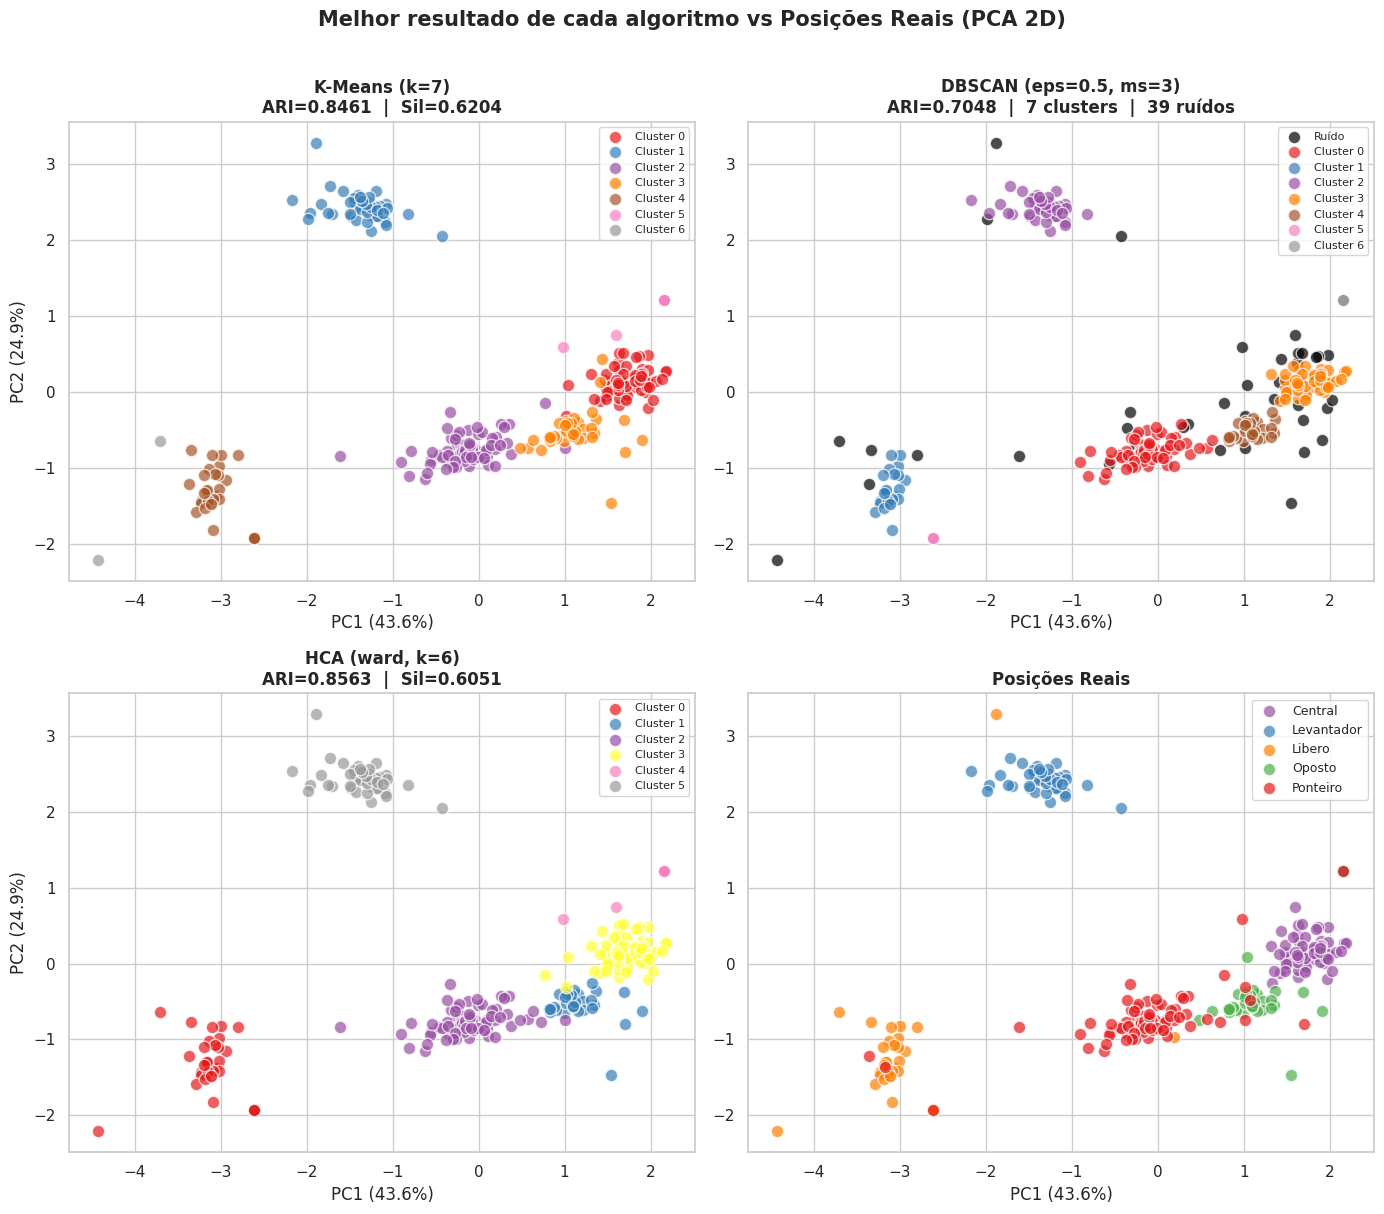

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Perform PCA to reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled_all)

cmap = plt.cm.Set1
pos_uniq = sorted(y.unique())
pc1_label = f'PC1 ({pca.explained_variance_ratio_[0]:.1%})'
pc2_label = f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'

def plot_clusters(ax, labels, title):
    for c in sorted(set(labels)):
        mask = labels == c
        color = 'black' if c == -1 else cmap(c / max(max(labels), 1))
        label = 'Ruído' if c == -1 else f'Cluster {c}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=color, label=label, alpha=0.7, s=80, edgecolors='w')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(pc1_label)
    ax.legend(fontsize=8, loc='upper right')

# (0,0) K-Means melhor k
plot_clusters(axes[0, 0], resultados_km_k[melhor_k_ari]['labels'],
              f'K-Means (k={melhor_k_ari})\nARI={resultados_km_k[melhor_k_ari]["ARI"]:.4f}  |  Sil={resultados_km_k[melhor_k_ari]["Silhouette"]:.4f}')
axes[0, 0].set_ylabel(pc2_label)

# (0,1) DBSCAN melhor config
plot_clusters(axes[0, 1], labels_db,
              f"DBSCAN (eps={melhor_db['eps']}, ms={melhor_db['min_samples']})\n"
              f"ARI={ari_db:.4f}  |  {melhor_db['n_clusters']} clusters  |  {melhor_db['n_ruido']} ruídos")

# (1,0) HCA melhor k
plot_clusters(axes[1, 0], resultados_hca_k[melhor_k_hca]['labels'],
              f'HCA (ward, k={melhor_k_hca})\nARI={resultados_hca_k[melhor_k_hca]["ARI"]:.4f}  |  Sil={resultados_hca_k[melhor_k_hca]["Silhouette"]:.4f}')
axes[1, 0].set_ylabel(pc2_label)

# (1,1) Posições reais
for pos in pos_uniq:
    mask = y == pos
    axes[1, 1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                       color=cores_posicao.get(pos, 'gray'),
                       label=pos, alpha=0.7, s=80, edgecolors='w')
axes[1, 1].set_title('Posições Reais', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel(pc1_label)
axes[1, 1].legend(fontsize=9, loc='upper right')

plt.suptitle('Melhor resultado de cada algoritmo vs Posições Reais (PCA 2D)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Análise dos resultados

Os quatro painéis comparam visualmente a melhor configuração de cada algoritmo contra as posições reais, projetadas em 2 dimensões via PCA.

**Levantador e Líbero continuam sendo recuperados com perfeição.** No painel das posições reais, Levantador (azul, topo) e Líbero (laranja, canto inferior esquerdo) formam grupos isolados e compactos. Os três algoritmos reproduzem essa separação sem exceção, cada um atribuindo um cluster exclusivo a cada posição, sem nenhum ponto invasor. Esse resultado é consistente desde o baseline (`k=5`) até as melhores configurações.

**Com mais clusters disponíveis, o Oposto finalmente ganha um cluster próprio no K-Means e na HCA.** Comparando com o painel de posições reais, onde o Oposto (verde) ocupa a região central-direita entre Ponteiro e Central, o K-Means (k=7) e a HCA (k=6) conseguem isolar essa região como um cluster distinto (Cluster 3 no K-Means, Cluster 3 na HCA). Essa é a principal diferença visual em relação ao baseline (`k=5`), onde o Oposto era absorvido por Ponteiro e Central.

**K-Means (k=7) e HCA (k=6) produzem partições visualmente muito semelhantes**, com a diferença de que o K-Means usa um cluster a mais para subdividir o Líbero em dois subgrupos (Cluster 4 e Cluster 6, visíveis no canto inferior esquerdo). Essa fragmentação do Líbero, com apenas 2 atletas no Cluster 6, reforça a interpretação de possível outlier já discutida na seção 7.3.

**O DBSCAN se destaca pelo ruído concentrado na zona de fronteira.** Os 39 pontos pretos (ruído) não estão espalhados aleatoriamente: eles se concentram na região de transição entre Ponteiro, Oposto e Central (PC1 ≈ 0 a 1.5), exatamente onde os outros dois algoritmos também mostram maior mistura de clusters. O DBSCAN está identificando como inclassificáveis os mesmos atletas que ocupam a fronteira tática entre essas três posições.

# 12. Conclusões

Os três algoritmos apresentaram comportamento notavelmente similar: todos recuperaram Levantador, Líbero e Ponteiro com alta fidelidade, e todos enfrentaram a mesma dificuldade com a sobreposição entre Oposto, Ponteiro e Central. A diferença entre eles está mais na forma de expressar essa dificuldade do que no resultado final: o K-Means absorveu o Oposto em outros clusters, o DBSCAN classificou os atletas de fronteira como ruído, e a HCA encontrou a mesma dificuldade que o K-MEANS, porém expôs a proximidade entre essas posições diretamente no dendrograma.

Entre os três, K-Means e HCA se destacam como os melhores candidatos para este dataset: ambos atingiram ARI próximo ou acima de 0,70 com `k=5`, e ao aumentar para 6 ou 7 clusters, ultrapassaram 0,84 de ARI. O DBSCAN, apesar de útil para revelar a estrutura de densidade e identificar zonas de fronteira, ficou limitado pelo descarte de atletas como ruído.

O principal resultado deste estudo demonstra que o dataset apresenta uma estrutura capaz de distinguir consistentemente as posições táticas, desde que seja adotada uma granularidade ligeiramente superior a `k=5`. Constatou-se que os cinco rótulos oficiais não contemplam toda a complexidade dos dados; os agrupamentos adicionais nessa faixa tendem a acomodar subperfis existentes e/ou outliers que, na configuração estrita de `k=5`, fragmentam clusters de posições distintas, como Oposto e Central.

## 12.2 Limitações do estudo

1. **Escopo temporal restrito:** o dataset cobre exclusivamente a VNL 2024 masculina. Estilos táticos e composições de elenco variam entre edições e ligas nacionais, o que limita a generalização dos clusters encontrados a contextos não vistos.

2. **Features limitadas ao volume de jogo:** as 6 variáveis `p_v_*` capturam apenas a proporção de participação em cada fundamento. A inclusão de dados de natureza diferente, como métricas biométricas (altura, envergadura, velocidade de salto), poderia introduzir discriminadores adicionais capazes de separar posições que se sobrepõem no espaço atual, como Oposto, Ponteiro e Centrais.

3. **Viés de participação:** atletas reservas com poucos jogos produzem perfis `p_v_*` instáveis, que podem distorcer centroides e fronteiras de densidade. Uma abordagem alternativa seria filtrar atletas com participação abaixo de um limiar mínimo de ações, tratando-os como outliers antes da clusterização.

## 12.3 Próximos passos

1. **Incorporar features de características biométricas**, que poderiam ajudar a separar melhor os subgrupos.

2. **Validação cross-torneio:** aplicar o mesmo pipeline de clusterização a dados de ligas nacionais ou edições anteriores da VNL, para medir se a estrutura de clusters encontrada é estável entre diferentes contextos competitivos.

3. **Análise de dados composicionais:** aplicar a transformação de log-ratio (ILR/CLR) antes da clusterização, para remover a restrição de soma = 1 e avaliar seu impacto na geometria dos clusters formados.

4. **Explorar cortes alternativos do dendrograma da HCA:** além de k=5, testar visualmente diferentes alturas de corte para identificar se a hierarquia sugere uma estrutura de sub-grupos (ex.: uma primeira divisão entre atacantes/defensores, e só depois as 5 posições), o que poderia enriquecer a interpretação tática além do que K-Means e DBSCAN conseguem expor isoladamente.
